# NYC Power Outage Vulnerability Analysis
**Date:** April 2026  
**Purpose:** Characterize NYC power outage patterns (2014–2023) and test whether community vulnerability (CVI) predicts worse outage frequency and duration at the county level.


## Executive Summary

- **Severe weather and seasonality** reliably drive outage frequency; summer and winter peaks survive county and year controls (Parts 1–5, 8b).
- **Resilience, not frequency, is the stronger vulnerability signal.** Higher-CVI counties experience longer outages — especially in the upper tail (p90, share >24 h) — more consistently than they experience more frequent ones (Parts 10–11).
- **Tract-level CVI analysis is not supported** by this dataset: outage measures are uniform within county-year. All CVI inference uses a **5-county panel** — treat coefficients as descriptive, not inferential (Part 8a).
- **Negative Binomial** fits outage counts substantially better than Poisson (overdispersion ≈ 41.7; AIC improvement ~1,746). All future count models should default to NegBin (Part 8b).
- **Direction is consistent across OLS and Ridge** for social-economic CVI in both frequency and duration outcomes, but magnitudes are uncertain at N=5 counties.


## Analysis Overview

**Data**: NYC power outage events (2014–2023) merged with Census tract-level Community Vulnerability Index (CVI) and NOAA severe-weather counts.

**Analysis stages**:
| Stage | Parts | Focus |
|-------|-------|-------|
| Descriptive | 1–6 | Tract-level trends, seasonality, severe-weather associations |
| Methodological | 7–8b | CVI integration, data-structure check, model-family validation |
| Inferential | 9–12 | County-year vulnerability models, duration analysis, robustness, mechanism |

> **Note on Parts 9b and 10b**: Parts 9 and 10 present initial county-year models. Parts 9b and 10b are upgraded versions of the same questions using theory-driven variable selection (9a) and unique-event granularity (10a). For final inference, prefer 9a over 9 and 10a over 10.

**Key findings**:
- Severe weather significantly predicts outage occurrence across NYC tracts, with the signal robust to rank-based tests.
- Both outage frequency and duration show increasing trends in a meaningful subset of tracts over 2014–2023, with summer months driving elevated counts.
- Within the merged dataset, outage measures are uniform within county-year — tract-level CVI regression is not identified; county-year is the appropriate unit.
- County-level CVI is associated with both more frequent and longer outages; the **duration (resilience) channel is the stronger and more consistent finding** across model families.

## Data at a Glance

| Item | Value |
|------|-------|
| Study window | 2014–2023 |
| Geography | NYC 5 counties (Bronx, Brooklyn, Manhattan, Queens, Staten Island) |
| Inferential model N | ~600 county-month observations (5 counties × 10 years × 12 months) |
| Outage source | Merged event file with NOAA severe-weather flags and Census tract CVI |

> **N note:** All county-month regression models rest on N≈600. P-values and CIs are descriptive approximations — not valid asymptotic inference.


## Setup

In [47]:
# Core imports (run once per session)
from __future__ import annotations

import os
import calendar
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from scipy.stats import kendalltau, norm, spearmanr

import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.multitest import multipletests
from statsmodels.stats.outliers_influence import variance_inflation_factor

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

from IPython.display import display

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 200)

# --- Paths -------------------------------------------------------------
# Point this at the folder that contains Outage_CVI_Events.csv on your
# machine. The default assumes the notebook sits in the Energy Project
# folder next to the CSV. Change this if your data lives elsewhere.
DATA_DIR = Path(os.environ.get("ENERGY_DATA_DIR", Path.cwd()))
OUT_DIR = Path.cwd() / "eda_local_outputs"
OUT_DIR.mkdir(exist_ok=True)

print("DATA_DIR:", DATA_DIR)
print("OUT_DIR :", OUT_DIR)

# --- Analysis constants -----------------------------------------------
NYC_COUNTIES = {
    "36005": "Bronx",
    "36047": "Brooklyn",
    "36061": "Manhattan",
    "36081": "Queens",
    "36085": "Staten Island",
}

MIN_YEARS = 6   # minimum per-tract time-series length for OLS / Kendall fits
RANDOM_STATE = 42


DATA_DIR: /Users/simonwang/Desktop/CU/Energy Project
OUT_DIR : /Users/simonwang/Desktop/CU/Energy Project/eda_local_outputs


## Part 0  Load, clean, NYC-only filter

In [48]:
# Load the merged CVI + outage event-level file.
# Note: ~900 MB. low_memory=False avoids dtype guessing surprises.
file_path = DATA_DIR / "Outage_CVI_Events.csv"
assert file_path.exists(), f"Not found: {file_path}"

df = pd.read_csv(file_path, low_memory=False)
print("Shape:", df.shape)
display(df.head(3))
print("\nColumns:", df.columns.tolist())


Shape: (3200875, 23)


,state,county,cvi_overall,cvi_baseline_all,cvi_baseline_health,cvi_baseline_social_econ,cvi_baseline_infra,cvi_baseline_env,cvi_climate_all,cvi_climate_health,cvi_climate_social_econ,cvi_climate_extreme_events,tract_fips,county_fips,outage_year,outage_start_time,outage_duration_hours,outage_min_customers,outage_max_customers,outage_mean_customers,outage_event_type,outage_end_time,outage_event_uid
0,NY,Bronx,0.535334,0.550426,0.642327,0.572482,0.369538,0.617356,0.515212,0.416614,0.526831,0.602192,36005000100,36005,2014,2014-11-02 22:15:00,0.75,708.0,708.0,708.000000,NaN,NaN,2014_7089
1,NY,Bronx,0.535334,0.550426,0.642327,0.572482,0.369538,0.617356,0.515212,0.416614,0.526831,0.602192,36005000100,36005,2014,2014-11-04 14:30:00,1.50,297.0,701.0,364.333333,NaN,NaN,2014_7090
2,NY,Bronx,0.535334,0.550426,0.642327,0.572482,0.369538,0.617356,0.515212,0.416614,0.526831,0.602192,36005000100,36005,2014,2014-11-04 21:00:00,0.25,296.0,296.0,296.000000,NaN,NaN,2014_7091



Columns: ['state', 'county', 'cvi_overall', 'cvi_baseline_all', 'cvi_baseline_health', 'cvi_baseline_social_econ', 'cvi_baseline_infra', 'cvi_baseline_env', 'cvi_climate_all', 'cvi_climate_health', 'cvi_climate_social_econ', 'cvi_climate_extreme_events', 'tract_fips', 'county_fips', 'outage_year', 'outage_start_time', 'outage_duration_hours', 'outage_min_customers', 'outage_max_customers', 'outage_mean_customers', 'outage_event_type', 'outage_end_time', 'outage_event_uid']


In [49]:
# --- Clean fields, NYC 5-county filter, severe-weather flag ---------
required_cols = [
    "county_fips",
    "tract_fips",
    "outage_start_time",
    "outage_duration_hours",
    "outage_event_type",
]
missing = [c for c in required_cols if c not in df.columns]
assert not missing, f"Missing required columns: {missing}"


def _clean_fips(series: pd.Series, width: int) -> pd.Series:
    """Cast to Int64 to strip any .0 float formatting, then zero-pad."""
    return (
        pd.to_numeric(series, errors="coerce")
        .astype("Int64")
        .astype(str)
        .str.zfill(width)
        .replace({"<NA>": np.nan})
    )


df_eda = df.copy()
df_eda["county_fips"] = _clean_fips(df_eda["county_fips"], 5)
df_eda["tract_fips"] = _clean_fips(df_eda["tract_fips"], 11)

# Keep only the NYC 5 counties
df_eda = df_eda[df_eda["county_fips"].isin(NYC_COUNTIES)].copy()

df_eda["event_dt"] = pd.to_datetime(df_eda["outage_start_time"], errors="coerce")
df_eda["year"] = df_eda["event_dt"].dt.year
df_eda["month"] = df_eda["event_dt"].dt.month
df_eda["duration_hours"] = pd.to_numeric(df_eda["outage_duration_hours"], errors="coerce")

event_text = df_eda["outage_event_type"].fillna("").astype(str).str.strip().str.lower()
df_eda["is_severe_weather"] = event_text.str.startswith("severe weather")
df_eda["severe_weather_flag"] = df_eda["is_severe_weather"].astype(int)

print("Rows after NYC filter :", len(df_eda))
print("Valid datetime rows   :", int(df_eda["event_dt"].notna().sum()))
print("Unique NYC counties   :", sorted(df_eda["county_fips"].dropna().unique().tolist()))
print("Unique tracts         :", int(df_eda["tract_fips"].nunique()))

year_simple = (
    df_eda.dropna(subset=["year"])
    .groupby("year", as_index=False)
    .agg(
        total_outages=("tract_fips", "size"),
        severe_weather_outages=("severe_weather_flag", "sum"),
        severe_weather_share=("severe_weather_flag", "mean"),
        avg_duration_hours=("duration_hours", "mean"),
    )
    .round({"severe_weather_share": 3, "avg_duration_hours": 2})
)
display(year_simple)


Rows after NYC filter : 3200875
Valid datetime rows   : 3200875
Unique NYC counties   : ['36005', '36047', '36061', '36081', '36085']
Unique tracts         : 2168


,year,total_outages,severe_weather_outages,severe_weather_share,avg_duration_hours
0,2014,17171,0,0.000,1.75
1,2015,280690,0,0.000,4.11
2,2016,296277,0,0.000,2.91
3,2017,227010,1560,0.007,3.35
4,2018,667269,215400,0.323,3.60
5,2019,306579,53248,0.174,4.08
6,2020,274108,29933,0.109,7.98
7,2021,319416,444,0.001,4.12
8,2022,587220,117283,0.200,2.10
9,2023,225135,3024,0.013,2.25


### Build the tract-year panel

In [50]:
annual = (
    df_eda.dropna(subset=["year"])
    .groupby(["tract_fips", "county_fips", "year"], as_index=False)
    .agg(
        outage_occurrence=("tract_fips", "size"),
        outage_duration_mean=("duration_hours", "mean"),
        severe_weather_count=("severe_weather_flag", "sum"),
    )
)
annual["outage_duration_mean"] = annual["outage_duration_mean"].round(2)
print("NYC tract-year panel shape:", annual.shape)
print("Unique tracts in panel   :", int(annual["tract_fips"].nunique()))
display(annual.head(10))


NYC tract-year panel shape: (20993, 6)
Unique tracts in panel   : 2168


,tract_fips,county_fips,year,outage_occurrence,outage_duration_mean,severe_weather_count
0,36005000100,36005,2014,6,1.12,0
1,36005000100,36005,2015,72,1.66,0
2,36005000100,36005,2016,123,2.07,0
3,36005000100,36005,2017,64,2.24,0
4,36005000100,36005,2018,304,4.25,137
5,36005000100,36005,2019,113,2.52,38
6,36005000100,36005,2020,120,9.59,11
7,36005000100,36005,2021,109,4.14,0
8,36005000100,36005,2022,217,2.16,61
9,36005000100,36005,2023,113,1.92,3


## Part 1  Severe Weather vs Outage Occurrence / Duration (per tract)

Per-tract OLS of outage occurrence on severe-weather count. Tracts with fewer than 2 distinct
observation years are excluded. FDR correction is applied across tract-level p-values.

A **Poisson GLM** is also fitted per tract alongside OLS to compare coefficient *directions*.
Because GLMs can fail on very small samples, only direction agreement is reported — not GLM p-values.

In [51]:
rows = []
for tract, g in annual.groupby("tract_fips"):
    n_years = int(g["year"].nunique())

    # --- OLS: occurrence ~ severe weather count ---
    if n_years >= MIN_YEARS and g["severe_weather_count"].nunique() > 1 \
            and g["outage_occurrence"].nunique() > 1:
        X = sm.add_constant(g["severe_weather_count"])
        y = g["outage_occurrence"]
        ols_fit = sm.OLS(y, X).fit()
        occ_beta = ols_fit.params["severe_weather_count"]
        occ_p = ols_fit.pvalues["severe_weather_count"]

        # Poisson GLM (compare direction only — small-sample p-values are unreliable)
        try:
            poi_fit = sm.GLM(y, X, family=sm.families.Poisson()).fit(disp=0)
            occ_poi_beta = poi_fit.params["severe_weather_count"]
            occ_direction_agree = int(np.sign(occ_beta) == np.sign(occ_poi_beta))
        except Exception:
            occ_poi_beta, occ_direction_agree = np.nan, np.nan
    else:
        occ_beta, occ_p = np.nan, np.nan
        occ_poi_beta, occ_direction_agree = np.nan, np.nan

    # --- OLS: log-duration ~ severe weather count ---
    gd = g.dropna(subset=["outage_duration_mean"]).copy()
    if len(gd) >= MIN_YEARS and gd["severe_weather_count"].nunique() > 1 \
            and gd["outage_duration_mean"].nunique() > 1:
        gd["log_dur"] = np.log1p(gd["outage_duration_mean"])
        X = sm.add_constant(gd["severe_weather_count"])
        model = sm.OLS(gd["log_dur"], X).fit()
        dur_beta = model.params["severe_weather_count"]
        dur_p = model.pvalues["severe_weather_count"]
    else:
        dur_beta, dur_p = np.nan, np.nan

    rows.append({
        "tract_fips": tract,
        "n_years": n_years,
        "occ_beta": occ_beta,
        "occ_p": occ_p,
        "occ_poi_beta": occ_poi_beta,
        "occ_ols_poi_direction_agree": occ_direction_agree,
        "dur_log_beta": dur_beta,
        "dur_p": dur_p,
    })

tract_sw = pd.DataFrame(rows)

# FDR (Benjamini-Hochberg) across tested tracts
for col, out in [("occ_p", "occ_q"), ("dur_p", "dur_q")]:
    mask = tract_sw[col].notna()
    if mask.any():
        _, q, _, _ = multipletests(tract_sw.loc[mask, col], method="fdr_bh")
        tract_sw.loc[mask, out] = q

# Significance flags based on FDR-corrected q-values
tract_sw["occ_sig_05"] = tract_sw["occ_q"] < 0.05
tract_sw["occ_sig_01"] = tract_sw["occ_q"] < 0.01
tract_sw["dur_sig_05"] = tract_sw["dur_q"] < 0.05
tract_sw["dur_sig_01"] = tract_sw["dur_q"] < 0.01

print(f"Tested tracts (occurrence): {int(tract_sw['occ_p'].notna().sum())}")
print(f"  FDR-significant tracts (occ, q<0.05): {int(tract_sw['occ_sig_05'].fillna(False).sum())}")
print(f"  FDR-significant tracts (occ, q<0.01): {int(tract_sw['occ_sig_01'].fillna(False).sum())}")
print(f"Tested tracts (duration):   {int(tract_sw['dur_p'].notna().sum())}")
print(f"  FDR-significant tracts (dur, q<0.05): {int(tract_sw['dur_sig_05'].fillna(False).sum())}")
print(f"  FDR-significant tracts (dur, q<0.01): {int(tract_sw['dur_sig_01'].fillna(False).sum())}")

# OLS vs Poisson direction agreement summary
agree_n = int(tract_sw["occ_ols_poi_direction_agree"].fillna(0).sum())
tested_n = int(tract_sw["occ_ols_poi_direction_agree"].notna().sum())
if tested_n > 0:
    print(f"\nPoisson vs OLS direction agreement (occurrence): {agree_n}/{tested_n} tracts "
          f"({100*agree_n/tested_n:.1f}%)")

display(tract_sw.sort_values("occ_q").head(15))
tract_sw.to_csv(OUT_DIR / "part1_tract_severe_weather.csv", index=False)


Tested tracts (occurrence): 2168
  FDR-significant tracts (occ, q<0.05): 1769
  FDR-significant tracts (occ, q<0.01): 1769
Tested tracts (duration): 2168
  FDR-significant tracts (dur, q<0.05): 111
  FDR-significant tracts (dur, q<0.01): 0


,tract_fips,n_years,occ_beta,occ_p,dur_log_beta,dur_p,occ_q,dur_q,occ_sig_05,occ_sig_01,dur_sig_05,dur_sig_01
0,36005000100,10,1.673571,0.000405,0.002542,0.491877,0.001128,0.6889,True,True,False,False
1730,36081051600,10,2.501896,0.000524,0.000679,0.688900,0.001128,0.6889,True,True,False,False
1729,36081051500,10,2.501896,0.000524,0.000679,0.688900,0.001128,0.6889,True,True,False,False
1728,36081051300,10,2.501896,0.000524,0.000679,0.688900,0.001128,0.6889,True,True,False,False
1727,36081051200,10,2.501896,0.000524,0.000679,0.688900,0.001128,0.6889,True,True,False,False
1726,36081051100,10,2.501896,0.000524,0.000679,0.688900,0.001128,0.6889,True,True,False,False
1725,36081051000,10,2.501896,0.000524,0.000679,0.688900,0.001128,0.6889,True,True,False,False
1724,36081050800,10,2.501896,0.000524,0.000679,0.688900,0.001128,0.6889,True,True,False,False
1723,36081050700,10,2.501896,0.000524,0.000679,0.688900,0.001128,0.6889,True,True,False,False
1722,36081050600,10,2.501896,0.000524,0.000679,0.688900,0.001128,0.6889,True,True,False,False


## Part 2  Outage Occurrence / Duration Trend Over Years (per tract)

Per-tract trend analysis using two methods:
1. **OLS on year** — parametric slope (sensitive to outliers, used for direction/magnitude)
2. **Kendall's τ + Theil-Sen slope** — non-parametric, robust to outliers/zero-inflation

Both sets of p-values are FDR-corrected (Benjamini-Hochberg). Concordance between OLS and
Kendall's τ directions is reported as a robustness check.

In [52]:
rows = []
for tract, g in annual.groupby("tract_fips"):
    g = g.sort_values("year")
    n_years = int(g["year"].nunique())

    # --- OLS year trend: occurrence ---
    if n_years >= MIN_YEARS and g["outage_occurrence"].nunique() > 1:
        X = sm.add_constant(g["year"])
        model = sm.OLS(g["outage_occurrence"], X).fit()
        occ_beta = model.params["year"]
        occ_p = model.pvalues["year"]
        # Kendall's tau + Theil-Sen
        occ_tau, occ_tau_p = kendalltau(g["year"], g["outage_occurrence"], nan_policy="omit")
        occ_ts_slope = stats.theilslopes(g["outage_occurrence"], g["year"])[0]
    else:
        occ_beta, occ_p = np.nan, np.nan
        occ_tau, occ_tau_p, occ_ts_slope = np.nan, np.nan, np.nan

    # --- OLS year trend: log-duration ---
    gd = g.dropna(subset=["outage_duration_mean"]).copy()
    if len(gd) >= MIN_YEARS and gd["outage_duration_mean"].nunique() > 1:
        gd["log_dur"] = np.log1p(gd["outage_duration_mean"])
        X = sm.add_constant(gd["year"])
        model = sm.OLS(gd["log_dur"], X).fit()
        dur_beta = model.params["year"]
        dur_p = model.pvalues["year"]
        # Kendall's tau + Theil-Sen
        dur_tau, dur_tau_p = kendalltau(gd["year"], gd["log_dur"], nan_policy="omit")
        dur_ts_slope = stats.theilslopes(gd["log_dur"], gd["year"])[0]
    else:
        dur_beta, dur_p = np.nan, np.nan
        dur_tau, dur_tau_p, dur_ts_slope = np.nan, np.nan, np.nan

    rows.append({
        "tract_fips": tract,
        "n_years": n_years,
        # OLS results
        "occ_slope_per_year": occ_beta,
        "occ_p": occ_p,
        "dur_log_slope_per_year": dur_beta,
        "dur_p": dur_p,
        # Kendall's tau results
        "occ_tau": occ_tau,
        "occ_tau_p": occ_tau_p,
        "occ_ts_slope": occ_ts_slope,
        "dur_tau": dur_tau,
        "dur_tau_p": dur_tau_p,
        "dur_ts_slope": dur_ts_slope,
    })

tract_trend = pd.DataFrame(rows)

# FDR correction — OLS p-values
for col, out in [("occ_p", "occ_q"), ("dur_p", "dur_q")]:
    mask = tract_trend[col].notna()
    if mask.any():
        _, q, _, _ = multipletests(tract_trend.loc[mask, col], method="fdr_bh")
        tract_trend.loc[mask, out] = q

# FDR correction — Kendall's tau p-values
for col, out in [("occ_tau_p", "occ_tau_q"), ("dur_tau_p", "dur_tau_q")]:
    mask = tract_trend[col].notna()
    if mask.any():
        _, q, _, _ = multipletests(tract_trend.loc[mask, col], method="fdr_bh")
        tract_trend.loc[mask, out] = q


def _dir_flag(df_, slope_col, sig_col):
    return np.where(
        df_[sig_col],
        np.where(df_[slope_col] > 0, "increasing", "decreasing"),
        "no_sig_trend",
    )


for lvl in (0.05, 0.01):
    tag = f"{int(lvl*100):02d}"
    tract_trend[f"occ_trend_sig_{tag}"] = tract_trend["occ_q"] < lvl
    tract_trend[f"dur_trend_sig_{tag}"] = tract_trend["dur_q"] < lvl
    tract_trend[f"occ_trend_dir_{tag}"] = _dir_flag(
        tract_trend, "occ_slope_per_year", f"occ_trend_sig_{tag}")
    tract_trend[f"dur_trend_dir_{tag}"] = _dir_flag(
        tract_trend, "dur_log_slope_per_year", f"dur_trend_sig_{tag}")
    # Kendall's tau significance flags
    tract_trend[f"occ_tau_sig_{tag}"] = tract_trend["occ_tau_q"] < lvl
    tract_trend[f"dur_tau_sig_{tag}"] = tract_trend["dur_tau_q"] < lvl

tract_trend["occ_trend_dir"] = tract_trend["occ_trend_dir_05"]
tract_trend["dur_trend_dir"] = tract_trend["dur_trend_dir_05"]

print("Tracts with >= MIN_YEARS:", int((tract_trend["n_years"] >= MIN_YEARS).sum()))

for label, col in [
    ("OLS occurrence, q<0.05", "occ_trend_sig_05"),
    ("OLS occurrence, q<0.01", "occ_trend_sig_01"),
    ("OLS duration,   q<0.05", "dur_trend_sig_05"),
    ("OLS duration,   q<0.01", "dur_trend_sig_01"),
    ("Tau occurrence, q<0.05", "occ_tau_sig_05"),
    ("Tau occurrence, q<0.01", "occ_tau_sig_01"),
    ("Tau duration,   q<0.05", "dur_tau_sig_05"),
    ("Tau duration,   q<0.01", "dur_tau_sig_01"),
]:
    print(f"  Significant tract trends ({label}):",
          int(tract_trend[col].fillna(False).sum()))

# Direction concordance between OLS and Kendall's tau
both_occ = tract_trend[tract_trend["occ_trend_sig_05"] | tract_trend["occ_tau_sig_05"]]
if len(both_occ) > 0:
    agree = (np.sign(both_occ["occ_slope_per_year"]) == np.sign(both_occ["occ_tau"])).sum()
    print(f"\nOLS vs Tau direction concordance (occ, sig in either at q<0.05): "
          f"{agree}/{len(both_occ)} ({100*agree/len(both_occ):.1f}%)")

print("\nOccurrence trend direction — OLS (q<0.05):")
display(tract_trend["occ_trend_dir_05"].value_counts(dropna=False)
        .rename_axis("occ_trend_dir").reset_index(name="n_tracts"))
print("Duration trend direction — OLS (q<0.05):")
display(tract_trend["dur_trend_dir_05"].value_counts(dropna=False)
        .rename_axis("dur_trend_dir").reset_index(name="n_tracts"))
tract_trend.to_csv(OUT_DIR / "part2_tract_year_trend.csv", index=False)


Tracts with >= MIN_YEARS : 2168
Significant tract trends (occurrence, q<0.05): 0
Significant tract trends (occurrence, q<0.01): 0
Significant tract trends (duration,   q<0.05): 0
Significant tract trends (duration,   q<0.01): 0

Occurrence trend direction (q<0.05):


,occ_trend_dir,n_tracts
0,no_sig_trend,2168


Duration trend direction (q<0.05):


,dur_trend_dir,n_tracts
0,no_sig_trend,2168


## Part 3  Month Effect in Each Year

Chi-square goodness-of-fit per year, with the expected monthly outage
count proportional to days in month (leap-year aware). Significant
'hot months' are flagged by FDR-corrected standardized residuals.

In [53]:
monthly = (
    df_eda.dropna(subset=["year", "month"])
    .groupby(["year", "month"], as_index=False)
    .size()
    .rename(columns={"size": "outage_count"})
)

year_rows = []
month_rows = []
for year, g in monthly.groupby("year"):
    year = int(year)
    months = np.arange(1, 13)
    obs = np.array([g.loc[g["month"] == m, "outage_count"].sum() for m in months], dtype=float)
    if obs.sum() == 0:
        continue

    days = np.array([calendar.monthrange(year, int(m))[1] for m in months], dtype=float)
    exp = obs.sum() * (days / days.sum())

    min_exp = float(exp.min())

    chi2_stat, chi2_p = stats.chisquare(f_obs=obs, f_exp=exp)
    # Chi-square is unreliable when any expected cell < 5
    chi2_valid = (min_exp >= 5)

    std_resid = (obs - exp) / np.sqrt(exp)
    resid_p = 2 * norm.sf(np.abs(std_resid))
    _, resid_q, _, _ = multipletests(resid_p, method="fdr_bh")

    year_rows.append({
        "year": year,
        "total_outages": int(obs.sum()),
        "chi2_stat": float(chi2_stat),
        "chi2_p": float(chi2_p),
        "min_expected_cell": float(min_exp),
        "chi2_valid": bool(chi2_valid),
    })
    for m, o, e, r, p, q in zip(months, obs, exp, std_resid, resid_p, resid_q):
        month_rows.append({
            "year": year,
            "month": int(m),
            "obs_count": int(o),
            "exp_count_days_adjusted": float(e),
            "std_resid": float(r),
            "resid_p": float(p),
            "resid_q": float(q),
            "high_month_sig_05": bool((r > 0) and (q < 0.05)),
            "high_month_sig_01": bool((r > 0) and (q < 0.01)),
        })

year_month_test = pd.DataFrame(year_rows).sort_values("year")
month_detail = pd.DataFrame(month_rows).sort_values(["year", "month"])

if not year_month_test.empty:
    _, q, _, _ = multipletests(year_month_test["chi2_p"], method="fdr_bh")
    year_month_test["chi2_q"] = q
    year_month_test["year_has_month_effect_sig_05"] = year_month_test["chi2_q"] < 0.05
    year_month_test["year_has_month_effect_sig_01"] = year_month_test["chi2_q"] < 0.01

print("Years with significant month effect (q<0.05):",
      int(year_month_test["year_has_month_effect_sig_05"].fillna(False).sum()))
print("Years with significant month effect (q<0.01):",
      int(year_month_test["year_has_month_effect_sig_01"].fillna(False).sum()))

# Chi-square validity check: flag years where expected cell count drops below 5
invalid_years = year_month_test[~year_month_test["chi2_valid"]]
if len(invalid_years) > 0:
    print(f"\n⚠️  Chi-square VALIDITY WARNING: {len(invalid_years)} year(s) have min expected "
          f"cell count < 5 → results unreliable for those years:")
    display(invalid_years[["year","total_outages","min_expected_cell","chi2_valid"]])
else:
    print(f"\n✓  Chi-square validity check passed: all years have min expected cell >= 5 "
          f"(min = {year_month_test['min_expected_cell'].min():.2f})")

display(year_month_test)

sig_months_05 = (
    month_detail[month_detail["high_month_sig_05"]]
    .sort_values(["year", "std_resid"], ascending=[True, False])
    .groupby("year", as_index=False).first()
    [["year", "month", "obs_count", "std_resid", "resid_q"]]
)
sig_months_01 = (
    month_detail[month_detail["high_month_sig_01"]]
    .sort_values(["year", "std_resid"], ascending=[True, False])
    .groupby("year", as_index=False).first()
    [["year", "month", "obs_count", "std_resid", "resid_q"]]
)
print("\nMost extreme significantly high month per year (q<0.05):")
display(sig_months_05)
print("Most extreme significantly high month per year (q<0.01):")
display(sig_months_01)

year_month_test.to_csv(OUT_DIR / "part3_year_month_chi2.csv", index=False)
month_detail.to_csv(OUT_DIR / "part3_month_detail.csv", index=False)


Years with significant month effect (q<0.05): 10
Years with significant month effect (q<0.01): 10


,year,total_outages,chi2_stat,chi2_p,chi2_q,year_has_month_effect_sig_05,year_has_month_effect_sig_01
0,2014,17171,1.004844e+05,0.0,0.0,True,True
1,2015,280690,1.030069e+05,0.0,0.0,True,True
2,2016,296277,1.641799e+05,0.0,0.0,True,True
3,2017,227010,3.511924e+04,0.0,0.0,True,True
4,2018,667269,1.092333e+06,0.0,0.0,True,True
5,2019,306579,1.388598e+05,0.0,0.0,True,True
6,2020,274108,1.346133e+05,0.0,0.0,True,True
7,2021,319416,7.494578e+04,0.0,0.0,True,True
8,2022,587220,1.786282e+05,0.0,0.0,True,True
9,2023,225135,4.323207e+04,0.0,0.0,True,True



Most extreme significantly high month per year (q<0.05):


,year,month,obs_count,std_resid,resid_q
0,2014,11,11715,274.271436,0.0
1,2015,6,48404,166.789634,0.0
2,2016,9,77368,340.632754,0.0
3,2017,3,36381,123.156388,0.0
4,2018,3,241848,777.856402,0.0
5,2019,7,74972,303.251655,0.0
6,2020,7,62749,259.447714,0.0
7,2021,2,56325,203.289325,0.0
8,2022,4,123690,343.322824,0.0
9,2023,7,37758,134.777937,0.0


Most extreme significantly high month per year (q<0.01):


,year,month,obs_count,std_resid,resid_q
0,2014,11,11715,274.271436,0.0
1,2015,6,48404,166.789634,0.0
2,2016,9,77368,340.632754,0.0
3,2017,3,36381,123.156388,0.0
4,2018,3,241848,777.856402,0.0
5,2019,7,74972,303.251655,0.0
6,2020,7,62749,259.447714,0.0
7,2021,2,56325,203.289325,0.0
8,2022,4,123690,343.322824,0.0
9,2023,7,37758,134.777937,0.0


## Part 4  Result Visualizations (effect size + significance)

Effect-size plots summarizing Parts 1–3, plus a Spearman-based robust version of the Part 1 severe-weather test. The rank-based test is more appropriate than per-tract OLS under extreme skew and zero-inflation in outage counts.

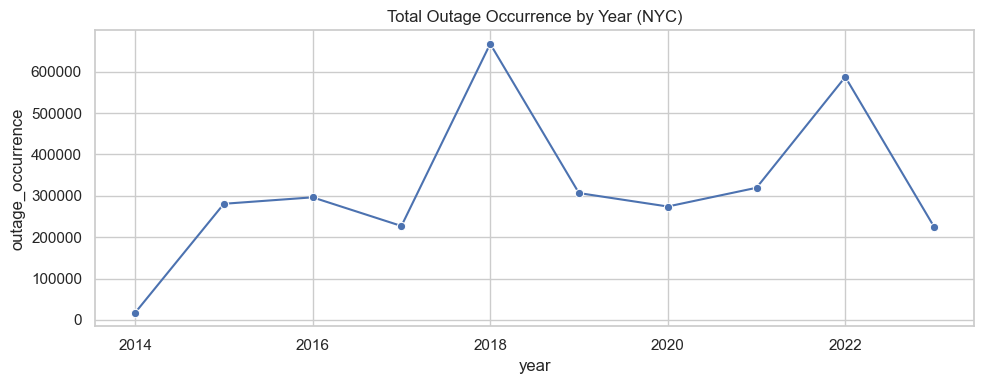

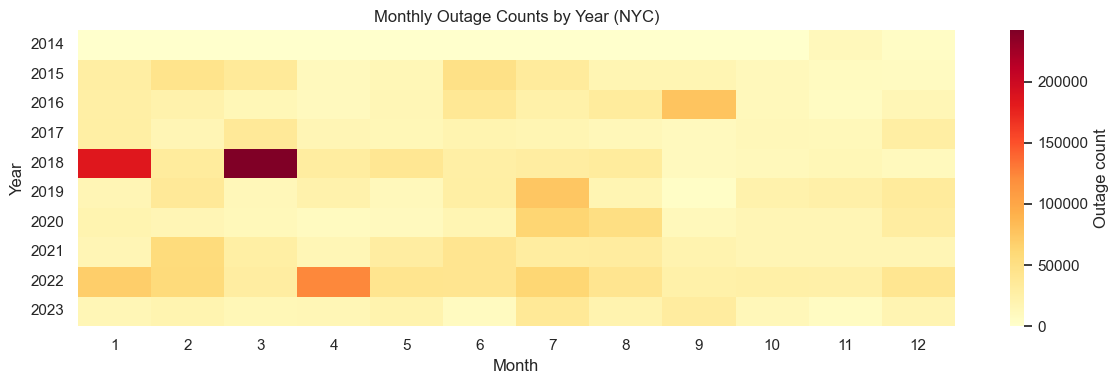

In [54]:
# Annual total + month-of-year heat map
annual_total = annual.groupby("year", as_index=False)["outage_occurrence"].sum()

plt.figure(figsize=(10, 4))
sns.lineplot(data=annual_total, x="year", y="outage_occurrence", marker="o")
plt.title("Total Outage Occurrence by Year (NYC)")
plt.tight_layout()
plt.savefig(OUT_DIR / "part4_total_by_year.png", dpi=150)
plt.show()

heat = monthly.pivot(index="year", columns="month", values="outage_count").fillna(0)
plt.figure(figsize=(12, 4))
sns.heatmap(heat, cmap="YlOrRd", cbar_kws={"label": "Outage count"})
plt.title("Monthly Outage Counts by Year (NYC)")
plt.xlabel("Month")
plt.ylabel("Year")
plt.tight_layout()
plt.savefig(OUT_DIR / "part4_month_year_heatmap.png", dpi=150)
plt.show()


In [55]:
# Robust per-tract Spearman version of the Part 1 severe-weather test
sw_rows = []
for tract, g in annual.groupby("tract_fips"):
    n_years = int(g["year"].nunique())

    if n_years >= MIN_YEARS and g["outage_occurrence"].nunique() > 1:
        occ_rho, occ_p = spearmanr(g["severe_weather_count"], g["outage_occurrence"], nan_policy="omit")
    else:
        occ_rho, occ_p = np.nan, np.nan

    gd = g.dropna(subset=["outage_duration_mean"]).copy()
    if len(gd) >= MIN_YEARS and gd["outage_duration_mean"].nunique() > 1:
        dur_rho, dur_p = spearmanr(gd["severe_weather_count"], gd["outage_duration_mean"], nan_policy="omit")
    else:
        dur_rho, dur_p = np.nan, np.nan

    sw_rows.append({
        "tract_fips": tract, "n_years": n_years,
        "occ_spearman_rho": occ_rho, "occ_spearman_p": occ_p,
        "dur_spearman_rho": dur_rho, "dur_spearman_p": dur_p,
    })

tract_sw_spearman = pd.DataFrame(sw_rows)

for col, out in [("occ_spearman_p", "occ_spearman_q"),
                 ("dur_spearman_p", "dur_spearman_q")]:
    mask = tract_sw_spearman[col].notna()
    if mask.any():
        _, q, _, _ = multipletests(tract_sw_spearman.loc[mask, col], method="fdr_bh")
        tract_sw_spearman.loc[mask, out] = q

for lvl in (0.05, 0.01):
    tag = f"{int(lvl*100):02d}"
    tract_sw_spearman[f"occ_sig_{tag}"] = tract_sw_spearman["occ_spearman_q"] < lvl
    tract_sw_spearman[f"dur_sig_{tag}"] = tract_sw_spearman["dur_spearman_q"] < lvl

print("Spearman-FDR significant tracts (SW vs Occurrence):")
print(f"  q<0.05: {int(tract_sw_spearman['occ_sig_05'].fillna(False).sum())}")
print(f"  q<0.01: {int(tract_sw_spearman['occ_sig_01'].fillna(False).sum())}")
print("Spearman-FDR significant tracts (SW vs Duration):")
print(f"  q<0.05: {int(tract_sw_spearman['dur_sig_05'].fillna(False).sum())}")
print(f"  q<0.01: {int(tract_sw_spearman['dur_sig_01'].fillna(False).sum())}")

display(tract_sw_spearman.head(10))
tract_sw_spearman.to_csv(OUT_DIR / "part4_spearman_sw.csv", index=False)


Spearman-FDR significant tracts (SW vs Occurrence):
  q<0.05: 1008
  q<0.01: 669
Spearman-FDR significant tracts (SW vs Duration):
  q<0.05: 0
  q<0.01: 0


,tract_fips,n_years,occ_spearman_rho,occ_spearman_p,dur_spearman_rho,dur_spearman_p,occ_spearman_q,dur_spearman_q,occ_sig_05,dur_sig_05,occ_sig_01,dur_sig_01
0,36005000100,10,0.758717,0.010951,0.510741,0.131413,0.023554,0.454391,True,False,False,False
1,36005000200,10,0.758717,0.010951,0.510741,0.131413,0.023554,0.454391,True,False,False,False
2,36005000400,10,0.758717,0.010951,0.510741,0.131413,0.023554,0.454391,True,False,False,False
3,36005001600,10,0.758717,0.010951,0.510741,0.131413,0.023554,0.454391,True,False,False,False
4,36005001900,10,0.758717,0.010951,0.510741,0.131413,0.023554,0.454391,True,False,False,False
5,36005002000,10,0.758717,0.010951,0.510741,0.131413,0.023554,0.454391,True,False,False,False
6,36005002300,10,0.758717,0.010951,0.510741,0.131413,0.023554,0.454391,True,False,False,False
7,36005002400,10,0.758717,0.010951,0.510741,0.131413,0.023554,0.454391,True,False,False,False
8,36005002500,10,0.758717,0.010951,0.510741,0.131413,0.023554,0.454391,True,False,False,False
9,36005002701,10,0.758717,0.010951,0.510741,0.131413,0.023554,0.454391,True,False,False,False


## Part 5  Month-by-Month Trend Over Years (NYC overall)

Checks whether each calendar month's outage count / duration is trending
up or down across 2014-2023. Uses Kendall's tau + Theil-Sen slope, which
are robust to outliers and do not assume normality.

,month,month_name,occ_tau,occ_slope_per_year,occ_q,occ_sig_05,dur_tau,dur_log_slope_per_year,dur_q,dur_sig_05
0,1,Jan,-0.388889,-1791.687500,0.520046,False,-0.777778,-0.140654,0.029101,True
1,2,Feb,0.166667,1014.333333,0.612202,False,-0.222222,-0.052295,0.635611,False
2,3,Mar,-0.222222,-970.857143,0.520046,False,-0.388889,-0.128008,0.537731,False
3,4,Apr,0.222222,918.142857,0.520046,False,-0.277778,-0.034196,0.537731,False
4,5,May,0.222222,945.645833,0.520046,False,-0.500000,-0.048581,0.451058,False
5,6,Jun,-0.277778,-2320.833333,0.520046,False,0.000000,-0.002992,1.000000,False
6,7,Jul,0.277778,2521.214286,0.520046,False,-0.277778,-0.031677,0.537731,False
7,8,Aug,0.222222,1418.916667,0.520046,False,0.277778,0.040895,0.537731,False
8,9,Sep,0.222222,1468.187500,0.520046,False,0.166667,0.055342,0.667857,False
9,10,Oct,0.500000,870.566667,0.451058,False,-0.166667,-0.016369,0.667857,False


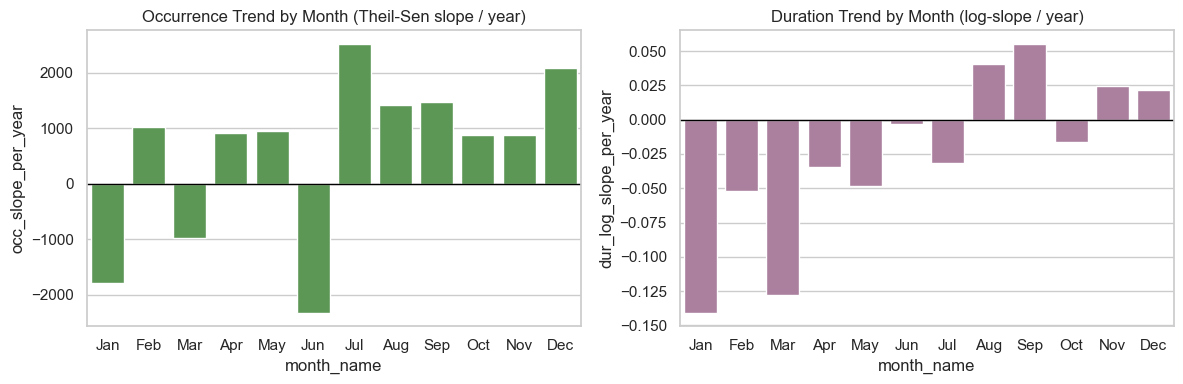

In [56]:
monthly_year = (
    df_eda.dropna(subset=["year", "month"])
    .groupby(["month", "year"], as_index=False)
    .agg(
        outage_occurrence=("tract_fips", "size"),
        outage_duration_mean=("duration_hours", "mean"),
    )
)

month_rows = []
for month, g in monthly_year.groupby("month"):
    g = g.sort_values("year")

    if len(g) >= MIN_YEARS and g["outage_occurrence"].nunique() > 1:
        occ_tau, occ_p = kendalltau(g["year"], g["outage_occurrence"], nan_policy="omit")
        occ_slope = stats.theilslopes(g["outage_occurrence"], g["year"])[0]
    else:
        occ_tau, occ_p, occ_slope = np.nan, np.nan, np.nan

    gd = g.dropna(subset=["outage_duration_mean"]).copy()
    if len(gd) >= MIN_YEARS and gd["outage_duration_mean"].nunique() > 1:
        gd["log_dur"] = np.log1p(gd["outage_duration_mean"])
        dur_tau, dur_p = kendalltau(gd["year"], gd["log_dur"], nan_policy="omit")
        dur_slope = stats.theilslopes(gd["log_dur"], gd["year"])[0]
    else:
        dur_tau, dur_p, dur_slope = np.nan, np.nan, np.nan

    month_rows.append({
        "month": int(month),
        "n_years": int(g["year"].nunique()),
        "occ_tau": occ_tau, "occ_p": occ_p, "occ_slope_per_year": occ_slope,
        "dur_tau": dur_tau, "dur_p": dur_p, "dur_log_slope_per_year": dur_slope,
    })

month_trend = pd.DataFrame(month_rows).sort_values("month")

for col, out in [("occ_p", "occ_q"), ("dur_p", "dur_q")]:
    mask = month_trend[col].notna()
    if mask.any():
        _, q, _, _ = multipletests(month_trend.loc[mask, col], method="fdr_bh")
        month_trend.loc[mask, out] = q

for lvl in (0.05, 0.01):
    tag = f"{int(lvl*100):02d}"
    month_trend[f"occ_sig_{tag}"] = month_trend["occ_q"] < lvl
    month_trend[f"dur_sig_{tag}"] = month_trend["dur_q"] < lvl

month_trend["month_name"] = month_trend["month"].map(
    {1: "Jan", 2: "Feb", 3: "Mar", 4: "Apr", 5: "May", 6: "Jun",
     7: "Jul", 8: "Aug", 9: "Sep", 10: "Oct", 11: "Nov", 12: "Dec"}
)
display(month_trend[[
    "month", "month_name", "occ_tau", "occ_slope_per_year", "occ_q",
    "occ_sig_05", "dur_tau", "dur_log_slope_per_year", "dur_q", "dur_sig_05",
]])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.barplot(data=month_trend, x="month_name", y="occ_slope_per_year",
            ax=axes[0], color="#54A24B")
axes[0].axhline(0, color="black", linewidth=1)
axes[0].set_title("Occurrence Trend by Month (Theil-Sen slope / year)")

sns.barplot(data=month_trend, x="month_name", y="dur_log_slope_per_year",
            ax=axes[1], color="#B279A2")
axes[1].axhline(0, color="black", linewidth=1)
axes[1].set_title("Duration Trend by Month (log-slope / year)")

plt.tight_layout()
plt.savefig(OUT_DIR / "part5_month_trend.png", dpi=150)
plt.show()
month_trend.to_csv(OUT_DIR / "part5_month_trend.csv", index=False)


## Part 6  Tract Seasonality Clustering

Cluster tracts by their monthly outage share to discover seasonality patterns. The number of clusters k is selected via a silhouette-score scan rather than a fixed value.

Eligible tracts (>= 50 outages): 2168


,k,silhouette,inertia
0,2,0.665578,5.455018e+00
1,3,0.729791,2.652272e+00
2,4,0.818231,1.258663e+00
3,5,1.000000,5.447208e-29
4,6,1.000000,5.360569e-29
5,7,1.000000,5.321850e-29
6,8,1.000000,5.327283e-29


Best-silhouette k: 5; using k_final=4


,cluster,n_tracts
0,0,111
1,1,1008
2,2,288
3,3,761


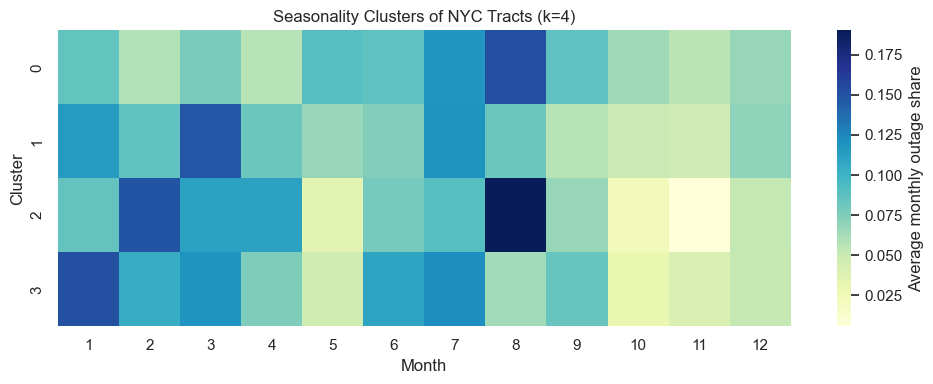

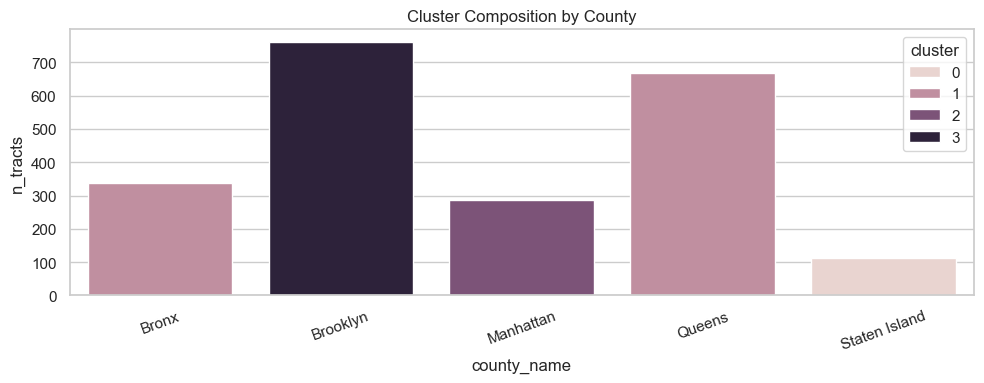

In [57]:
tract_month = (
    df_eda.dropna(subset=["month"])
    .groupby(["tract_fips", "month"])
    .size()
    .unstack(fill_value=0)
)
for m in range(1, 13):
    if m not in tract_month.columns:
        tract_month[m] = 0
tract_month = tract_month[sorted(tract_month.columns)]

tract_total = tract_month.sum(axis=1)
MIN_TOTAL_OUTAGES = 50
eligible = tract_month.loc[tract_total >= MIN_TOTAL_OUTAGES]
print(f"Eligible tracts (>= {MIN_TOTAL_OUTAGES} outages): {len(eligible)}")

if len(eligible) >= 4:
    eligible_share = eligible.div(eligible.sum(axis=1), axis=0)

    # Silhouette scan for k
    sil_rows = []
    for k in range(2, min(9, len(eligible_share))):
        km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=20).fit(eligible_share)
        sil = silhouette_score(eligible_share, km.labels_)
        sil_rows.append({"k": k, "silhouette": sil, "inertia": km.inertia_})

    sil_df = pd.DataFrame(sil_rows)
    display(sil_df)

    best_k = int(sil_df.sort_values("silhouette", ascending=False).iloc[0]["k"])
    # Let silhouette score drive k (no arbitrary cap).
    # If best_k > 6, neighbourhoods stop being interpretable — soft-cap at 6 with a warning.
    k_final = best_k if best_k <= 6 else 6
    if best_k > 6:
        print(f"Note: best silhouette k={best_k} > 6; capping at k_final=6 for interpretability.")
    else:
        print(f"Best-silhouette k: {best_k}; using k_final={k_final} (no cap applied)")
    best_sil = float(sil_df.loc[sil_df["k"] == k_final, "silhouette"].values[0])
    print(f"Final silhouette score (k={k_final}): {best_sil:.4f}  "
          f"(0=random overlap, 1=perfect separation)")
    # Silhouette plot
    plt.figure(figsize=(7, 3))
    sns.lineplot(data=sil_df, x="k", y="silhouette", marker="o")
    plt.axvline(k_final, color="red", linestyle="--", label=f"chosen k={k_final}")
    plt.title("Silhouette Score vs. Number of Clusters")
    plt.xlabel("k"); plt.ylabel("Silhouette score"); plt.legend()
    plt.tight_layout()
    plt.savefig(OUT_DIR / "part6_silhouette_scan.png", dpi=150)
    plt.show()

    kmeans = KMeans(n_clusters=k_final, random_state=RANDOM_STATE, n_init=20)
    labels = kmeans.fit_predict(eligible_share)
    cluster_df = eligible_share.copy()
    cluster_df["cluster"] = labels
    cluster_df["county_fips"] = cluster_df.index.to_series().astype(str).str[:5]
    cluster_df["county_name"] = cluster_df["county_fips"].map(NYC_COUNTIES)

    cluster_sizes = cluster_df["cluster"].value_counts().sort_index()        .rename_axis("cluster").reset_index(name="n_tracts")
    display(cluster_sizes)

    cluster_profile = cluster_df.groupby("cluster")[list(range(1, 13))].mean()

    plt.figure(figsize=(10, 4))
    sns.heatmap(cluster_profile, cmap="YlGnBu",
                cbar_kws={"label": "Average monthly outage share"})
    plt.xlabel("Month")
    plt.ylabel("Cluster")
    plt.title(f"Seasonality Clusters of NYC Tracts (k={k_final})")
    plt.tight_layout()
    plt.savefig(OUT_DIR / "part6_cluster_profile.png", dpi=150)
    plt.show()

    county_mix = (
        cluster_df.groupby(["county_name", "cluster"]).size()
        .reset_index(name="n_tracts")
    )
    plt.figure(figsize=(10, 4))
    sns.barplot(data=county_mix, x="county_name", y="n_tracts", hue="cluster")
    plt.title("Cluster Composition by County")
    plt.xticks(rotation=20)
    plt.tight_layout()
    plt.savefig(OUT_DIR / "part6_cluster_by_county.png", dpi=150)
    plt.show()

    cluster_df.reset_index().to_csv(OUT_DIR / "part6_clusters.csv", index=False)
else:
    print("Too few eligible tracts to cluster.")
    cluster_df = None


## Appendix: Part 7  CVI Variables + Exploratory Tract-Year Regressions

> **⚠️  EXPLORATORY ONLY — do not report p-values from this section.**
>
> As established in Part 8, outage measures are **identical across all tracts sharing the same county-year**. Tract-level CVI regressions cannot identify a tract-specific effect — pseudo-replication inflates N and deflates SEs artificially.
>
> **Use this section only to:**
> - Visualise marginal distributions of CVI and trend slopes
> - Generate hypotheses for the county-year models in Parts 9–12
>
> **Primary inferential results are in Parts 9–12.**
>
> ⛔ **Outputs below are retained for reference only and should not be cited in any report.**


In [58]:
candidate_cvi_cols = [
    "cvi_overall",
    "cvi_baseline_all",
    "cvi_baseline_health",
    "cvi_baseline_social_econ",
    "cvi_baseline_infra",
    "cvi_baseline_env",
    "cvi_climate_all",
    "cvi_climate_health",
    "cvi_climate_social_econ",
    "cvi_climate_extreme_events",
]
cvi_cols = [c for c in candidate_cvi_cols if c in df_eda.columns]
assert cvi_cols, "No CVI columns found in df_eda."

tract_cvi = (
    df_eda[["tract_fips", "county_fips"] + cvi_cols]
    .sort_values(["tract_fips", "county_fips"])
    .groupby(["tract_fips", "county_fips"], as_index=False)
    .first()
)

annual_cvi = annual.merge(tract_cvi, on=["tract_fips", "county_fips"], how="left")
annual_cvi["year_centered"] = annual_cvi["year"] - annual_cvi["year"].mean()
annual_cvi["log_outage_duration_mean"] = np.log1p(annual_cvi["outage_duration_mean"])
annual_cvi["severe_weather_share"] = np.where(
    annual_cvi["outage_occurrence"] > 0,
    annual_cvi["severe_weather_count"] / annual_cvi["outage_occurrence"],
    np.nan,
)

tract_profile = (
    annual_cvi.groupby(["tract_fips", "county_fips"], as_index=False)
    .agg(
        avg_outage_occurrence=("outage_occurrence", "mean"),
        avg_duration_hours=("outage_duration_mean", "mean"),
        avg_severe_weather_share=("severe_weather_share", "mean"),
        total_outages=("outage_occurrence", "sum"),
        years_observed=("year", "nunique"),
    )
)

trend_with_cvi = (
    tract_trend.merge(tract_profile, on="tract_fips", how="left")
    .merge(tract_cvi, on=["tract_fips", "county_fips"], how="left")
)
print("Available CVI columns:", cvi_cols)
display(trend_with_cvi.head())


Available CVI columns: ['cvi_overall', 'cvi_baseline_all', 'cvi_baseline_health', 'cvi_baseline_social_econ', 'cvi_baseline_infra', 'cvi_baseline_env', 'cvi_climate_all', 'cvi_climate_health', 'cvi_climate_social_econ', 'cvi_climate_extreme_events']


,tract_fips,n_years,occ_slope_per_year,occ_p,dur_log_slope_per_year,dur_p,occ_q,dur_q,occ_trend_sig_05,dur_trend_sig_05,occ_trend_dir_05,dur_trend_dir_05,occ_trend_sig_01,dur_trend_sig_01,occ_trend_dir_01,dur_trend_dir_01,occ_trend_dir,dur_trend_dir,county_fips,avg_outage_occurrence,avg_duration_hours,avg_severe_weather_share,total_outages,years_observed,cvi_overall,cvi_baseline_all,cvi_baseline_health,cvi_baseline_social_econ,cvi_baseline_infra,cvi_baseline_env,cvi_climate_all,cvi_climate_health,cvi_climate_social_econ,cvi_climate_extreme_events
0,36005000100,10,11.424242,0.229903,0.059499,0.261187,0.445424,0.672561,False,False,no_sig_trend,no_sig_trend,False,False,no_sig_trend,no_sig_trend,no_sig_trend,no_sig_trend,36005,124.1,3.167,0.118626,1241,10,0.535334,0.550426,0.642327,0.572482,0.369538,0.617356,0.515212,0.416614,0.526831,0.602192
1,36005000200,10,11.424242,0.229903,0.059499,0.261187,0.445424,0.672561,False,False,no_sig_trend,no_sig_trend,False,False,no_sig_trend,no_sig_trend,no_sig_trend,no_sig_trend,36005,124.1,3.167,0.118626,1241,10,0.557262,0.618647,0.536897,0.807660,0.583026,0.547004,0.475415,0.428630,0.440171,0.557442
2,36005000400,10,11.424242,0.229903,0.059499,0.261187,0.445424,0.672561,False,False,no_sig_trend,no_sig_trend,False,False,no_sig_trend,no_sig_trend,no_sig_trend,no_sig_trend,36005,124.1,3.167,0.118626,1241,10,0.526520,0.540622,0.469100,0.612295,0.548589,0.532504,0.507718,0.430387,0.507025,0.585742
3,36005001600,10,11.424242,0.229903,0.059499,0.261187,0.445424,0.672561,False,False,no_sig_trend,no_sig_trend,False,False,no_sig_trend,no_sig_trend,no_sig_trend,no_sig_trend,36005,124.1,3.167,0.118626,1241,10,0.577907,0.670849,0.632347,0.826614,0.607396,0.617041,0.453984,0.437604,0.422238,0.502111
4,36005001900,10,11.424242,0.229903,0.059499,0.261187,0.445424,0.672561,False,False,no_sig_trend,no_sig_trend,False,False,no_sig_trend,no_sig_trend,no_sig_trend,no_sig_trend,36005,124.1,3.167,0.118626,1241,10,0.594053,0.649981,0.578240,0.805831,0.457360,0.758491,0.519482,0.476253,0.491076,0.591116


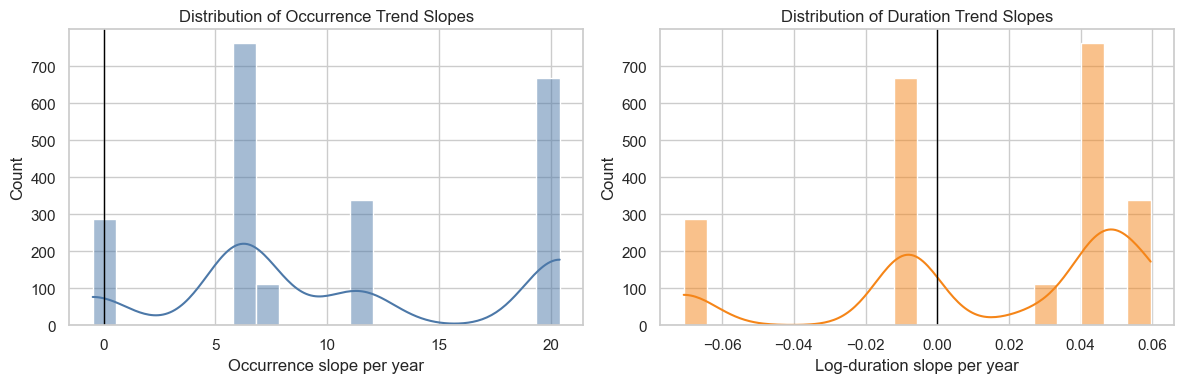

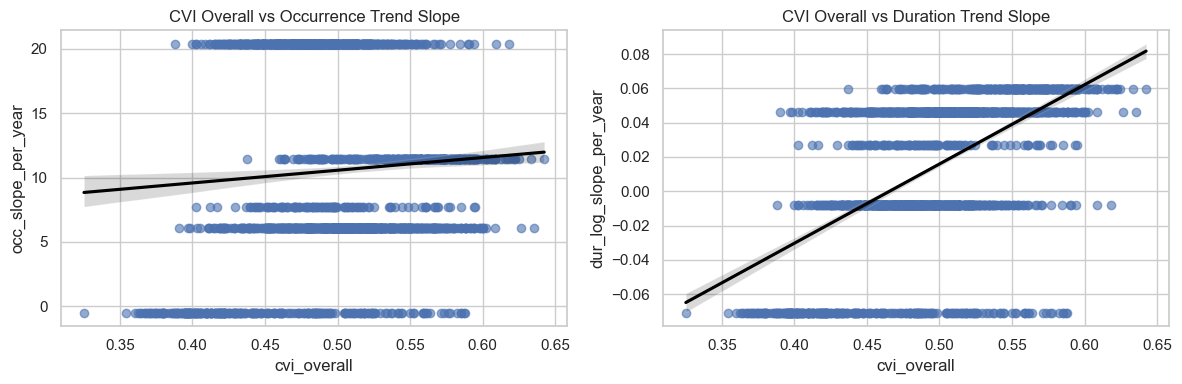

,cvi_variable,outcome,n,spearman_rho,p_value,abs_rho
19,cvi_baseline_infra,dur_log_slope_per_year,2168,0.641223,2.128960e-251,0.641223
3,cvi_overall,dur_log_slope_per_year,2168,0.561802,1.287930e-180,0.561802
7,cvi_baseline_all,dur_log_slope_per_year,2168,0.557022,5.956850e-177,0.557022
11,cvi_baseline_health,dur_log_slope_per_year,2168,0.491342,3.849304e-132,0.491342
15,cvi_baseline_social_econ,dur_log_slope_per_year,2168,0.478846,1.132958e-124,0.478846
33,cvi_climate_social_econ,avg_duration_hours,2168,0.401617,7.890874e-85,0.401617
38,cvi_climate_extreme_events,occ_slope_per_year,2168,-0.348585,5.709263e-63,0.348585
36,cvi_climate_extreme_events,avg_outage_occurrence,2168,-0.313508,1.188174e-50,0.313508
32,cvi_climate_social_econ,avg_outage_occurrence,2168,0.294988,8.763904e-45,0.294988
37,cvi_climate_extreme_events,avg_duration_hours,2168,0.264237,5.845735e-36,0.264237


In [59]:
# Trend-slope distributions + CVI scatter
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(trend_with_cvi["occ_slope_per_year"].dropna(), bins=20, kde=True,
             color="#4C78A8", ax=axes[0])
axes[0].axvline(0, color="black", linewidth=1)
axes[0].set_title("Distribution of Occurrence Trend Slopes")
axes[0].set_xlabel("Occurrence slope per year")

sns.histplot(trend_with_cvi["dur_log_slope_per_year"].dropna(), bins=20, kde=True,
             color="#F58518", ax=axes[1])
axes[1].axvline(0, color="black", linewidth=1)
axes[1].set_title("Distribution of Duration Trend Slopes")
axes[1].set_xlabel("Log-duration slope per year")
plt.tight_layout()
plt.savefig(OUT_DIR / "part7_slope_distributions.png", dpi=150)
plt.show()

if "cvi_overall" in trend_with_cvi.columns:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    sns.regplot(data=trend_with_cvi, x="cvi_overall", y="occ_slope_per_year",
                scatter_kws={"alpha": 0.6}, line_kws={"color": "black"}, ax=axes[0])
    axes[0].set_title("CVI Overall vs Occurrence Trend Slope")
    sns.regplot(data=trend_with_cvi, x="cvi_overall", y="dur_log_slope_per_year",
                scatter_kws={"alpha": 0.6}, line_kws={"color": "black"}, ax=axes[1])
    axes[1].set_title("CVI Overall vs Duration Trend Slope")
    plt.tight_layout()
    plt.savefig(OUT_DIR / "part7_cvi_scatter.png", dpi=150)
    plt.show()

# Spearman correlation between CVI columns and trend outcomes
corr_outcomes = [
    "avg_outage_occurrence",
    "avg_duration_hours",
    "occ_slope_per_year",
    "dur_log_slope_per_year",
]
corr_rows = []
for cvi_col in cvi_cols:
    for outcome_col in corr_outcomes:
        temp = trend_with_cvi[[cvi_col, outcome_col]].dropna()
        if len(temp) >= 6 and temp[cvi_col].nunique() > 1 and temp[outcome_col].nunique() > 1:
            rho, p = stats.spearmanr(temp[cvi_col], temp[outcome_col])
            corr_rows.append({
                "cvi_variable": cvi_col,
                "outcome": outcome_col,
                "n": len(temp),
                "spearman_rho": rho,
                "p_value": p,
                "abs_rho": abs(rho),
            })
corr_df = pd.DataFrame(corr_rows).sort_values(["abs_rho", "p_value"],
                                              ascending=[False, True])
display(corr_df)
corr_df.to_csv(OUT_DIR / "part7_cvi_spearman.csv", index=False)


In [60]:
# Exploratory OLS regressions at tract-year level -- expected to be
# optimistic per Part 8 diagnostic; kept for hypothesis generation.
def pick_first(options, exclude=None):
    exclude = set(exclude or [])
    for col in options:
        if col in cvi_cols and col not in exclude:
            return col
    for col in cvi_cols:
        if col not in exclude:
            return col
    return cvi_cols[0]

cvi_main = pick_first(["cvi_overall"])
cvi_social = pick_first(["cvi_baseline_social_econ", "cvi_baseline_all"], exclude=[cvi_main])
cvi_climate = pick_first(["cvi_climate_extreme_events", "cvi_climate_all"],
                         exclude=[cvi_main, cvi_social])
print("Regression CVI terms:", cvi_main, "|", cvi_social, "|", cvi_climate)

occ_formulas = {
    "occ_linear": f"outage_occurrence ~ year_centered + severe_weather_count + {cvi_main}",
    "occ_interaction": f"outage_occurrence ~ year_centered + severe_weather_count * {cvi_climate} + {cvi_social}",
    "occ_nonlinear": f"outage_occurrence ~ year_centered + severe_weather_count + {cvi_main} + I({cvi_main} ** 2) + severe_weather_count:{cvi_main}",
}
dur_formulas = {
    "dur_linear": f"log_outage_duration_mean ~ year_centered + severe_weather_count + {cvi_main}",
    "dur_interaction": f"log_outage_duration_mean ~ year_centered + severe_weather_count * {cvi_climate} + {cvi_social}",
    "dur_nonlinear": f"log_outage_duration_mean ~ year_centered + severe_weather_count + {cvi_main} + I({cvi_main} ** 2) + severe_weather_count:{cvi_main}",
}

def fit_formula_set(data, formulas, outcome_label):
    model_rows, coef_rows = [], []
    for model_name, formula in formulas.items():
        # Cluster-robust SE by county_fips -- closer to reality than classical
        # SEs here because the same county-year outcome is repeated over tracts.
        # Drop rows with any NaN in the formula terms so that the `groups`
        # vector and the model observations line up exactly.
        y_name = formula.split("~", 1)[0].strip()
        used = [y_name] + [
            t for t in cvi_cols + [
                "year_centered", "severe_weather_count", "county_fips",
            ] if t in data.columns
        ]
        sub = data.dropna(subset=[c for c in used if c in data.columns]).copy()
        model = smf.ols(formula, data=sub).fit(
            cov_type="cluster",
            cov_kwds={"groups": sub["county_fips"]},
        )
        model_rows.append({
            "outcome": outcome_label, "model": model_name, "formula": formula,
            "nobs": int(model.nobs), "r_squared": model.rsquared,
            "adj_r_squared": model.rsquared_adj, "aic": model.aic, "bic": model.bic,
        })
        coef_frame = pd.DataFrame({
            "outcome": outcome_label, "model": model_name,
            "term": model.params.index, "coef": model.params.values,
            "p_value": model.pvalues.values,
        })
        coef_rows.append(coef_frame[coef_frame["term"] != "Intercept"])
    return pd.DataFrame(model_rows), pd.concat(coef_rows, ignore_index=True)

occ_model_summary, occ_coef = fit_formula_set(
    annual_cvi.dropna(subset=["outage_occurrence"]), occ_formulas, "Occurrence")
dur_model_summary, dur_coef = fit_formula_set(
    annual_cvi.dropna(subset=["log_outage_duration_mean"]), dur_formulas, "Log duration")

display(pd.concat([occ_model_summary, dur_model_summary], ignore_index=True))

coef_summary = (
    pd.concat([occ_coef, dur_coef], ignore_index=True)
    .assign(abs_coef=lambda d: d["coef"].abs())
    .sort_values(["outcome", "abs_coef", "p_value"], ascending=[True, False, True])
)
display(coef_summary)

print(
    "Interpretation note: these tract-year R² values are inflated because the"
    " county-year outage outcomes are replicated across tracts within each"
    " county-year (see Part 8). The county-year models are the defensible ones."
)


Regression CVI terms: cvi_overall | cvi_baseline_social_econ | cvi_climate_extreme_events


,outcome,model,formula,nobs,r_squared,adj_r_squared,aic,bic
0,Occurrence,occ_linear,outage_occurrence ~ year_centered + severe_wea...,20993,0.650609,0.650559,236501.937778,236533.745555
1,Occurrence,occ_interaction,outage_occurrence ~ year_centered + severe_wea...,20993,0.659810,0.659729,235945.681613,235993.393279
2,Occurrence,occ_nonlinear,outage_occurrence ~ year_centered + severe_wea...,20993,0.684456,0.684380,234366.930288,234414.641954
3,Log duration,dur_linear,log_outage_duration_mean ~ year_centered + sev...,20993,0.016812,0.016672,24222.372228,24254.180005
4,Log duration,dur_interaction,log_outage_duration_mean ~ year_centered + sev...,20993,0.020161,0.019928,24154.739556,24202.451222
5,Log duration,dur_nonlinear,log_outage_duration_mean ~ year_centered + sev...,20993,0.019897,0.019663,24160.410851,24208.122517


,outcome,model,term,coef,p_value,abs_coef
24,Log duration,dur_nonlinear,I(cvi_overall ** 2),-3.084051,7.401221e-01,3.084051
23,Log duration,dur_nonlinear,cvi_overall,2.806926,7.574862e-01,2.806926
18,Log duration,dur_interaction,cvi_climate_extreme_events,-0.237046,6.292127e-01,0.237046
20,Log duration,dur_interaction,cvi_baseline_social_econ,-0.131562,5.554698e-01,0.131562
21,Log duration,dur_nonlinear,year_centered,0.019700,3.256563e-01,0.019700
13,Log duration,dur_linear,year_centered,0.019636,3.204222e-01,0.019636
16,Log duration,dur_interaction,year_centered,0.019530,3.219896e-01,0.019530
15,Log duration,dur_linear,cvi_overall,-0.017217,9.803015e-01,0.017217
25,Log duration,dur_nonlinear,severe_weather_count:cvi_overall,0.013279,3.677988e-01,0.013279
22,Log duration,dur_nonlinear,severe_weather_count,-0.007141,3.347536e-01,0.007141


Interpretation note: these tract-year R² values are inflated because the county-year outage outcomes are replicated across tracts within each county-year (see Part 8). The county-year models are the defensible ones.


> **Note:** Model outputs above are biased due to pseudo-replication (see Part 8a). Retained for hypothesis generation only — **do not cite in any report**. For valid CVI inference see Parts 9–12.


## Part 8a  Data-Structure Check + County-Year Panel

Important diagnostic: within each county-year, the outage measures in this
merged file are identical across tracts. We verify this, then collapse
to a balanced county-year panel and add HC3 robust SEs plus a VIF check.

In [61]:
# Diagnose within-county-year variation
county_year_consistency = (
    annual.groupby(["county_fips", "year"], as_index=False)
    .agg(
        n_tracts=("tract_fips", "nunique"),
        occ_unique=("outage_occurrence", "nunique"),
        dur_unique=("outage_duration_mean", lambda s: s.round(10).nunique()),
        sw_unique=("severe_weather_count", "nunique"),
    )
)
display(county_year_consistency.head(10))
print("Share of county-year cells with identical outage occurrence across all tracts:",
      round((county_year_consistency["occ_unique"] == 1).mean(), 3))
print("Share of county-year cells with identical mean duration across all tracts:",
      round((county_year_consistency["dur_unique"] == 1).mean(), 3))
print("Share of county-year cells with identical severe-weather count across all tracts:",
      round((county_year_consistency["sw_unique"] == 1).mean(), 3))


,county_fips,year,n_tracts,occ_unique,dur_unique,sw_unique
0,36005,2014,339,1,1,1
1,36005,2015,339,1,1,1
2,36005,2016,339,1,1,1
3,36005,2017,339,1,1,1
4,36005,2018,339,1,1,1
5,36005,2019,339,1,1,1
6,36005,2020,339,1,1,1
7,36005,2021,339,1,1,1
8,36005,2022,339,1,1,1
9,36005,2023,339,1,1,1


Share of county-year cells with identical outage occurrence across all tracts: 1.0
Share of county-year cells with identical mean duration across all tracts: 1.0
Share of county-year cells with identical severe-weather count across all tracts: 1.0


In [62]:
# Build a balanced county-year panel with county-level CVI summaries
df_county = df_eda.copy()
for col in ["outage_mean_customers", "outage_max_customers"]:
    if col in df_county.columns:
        df_county[col] = pd.to_numeric(df_county[col], errors="coerce")

county_year = (
    df_county.dropna(subset=["year"])
    .groupby(["county_fips", "year"], as_index=False)
    .agg(
        outage_occurrence=("outage_event_uid", "nunique"),
        outage_duration_mean=("duration_hours", "mean"),
        severe_weather_count=("severe_weather_flag", "sum"),
        severe_weather_share=("severe_weather_flag", "mean"),
        outage_mean_customers_mean=("outage_mean_customers", "mean"),
        outage_max_customers_mean=("outage_max_customers", "mean"),
    )
)

county_grid = pd.DataFrame({"county_fips": sorted(NYC_COUNTIES)})
year_grid = pd.DataFrame({"year": sorted(df_county["year"].dropna().astype(int).unique())})
county_grid["key"] = 1
year_grid["key"] = 1
county_year_balanced = (
    county_grid.merge(year_grid, on="key").drop(columns="key")
    .merge(county_year, on=["county_fips", "year"], how="left")
)
county_year_balanced["county_name"] = county_year_balanced["county_fips"].map(NYC_COUNTIES)
county_year_balanced["outage_occurrence"] = county_year_balanced["outage_occurrence"].fillna(0)
county_year_balanced["severe_weather_count"] = county_year_balanced["severe_weather_count"].fillna(0)
county_year_balanced["severe_weather_share"] = county_year_balanced["severe_weather_share"].fillna(0)
county_year_balanced["year_centered"] = (
    county_year_balanced["year"] - county_year_balanced["year"].mean()
)
county_year_balanced["log_outage_occurrence"] = np.log1p(county_year_balanced["outage_occurrence"])
county_year_balanced["log_outage_duration_mean"] = np.log1p(county_year_balanced["outage_duration_mean"])
county_year_balanced["log_outage_mean_customers"] = np.log1p(county_year_balanced["outage_mean_customers_mean"])

citywide_cvi_q75 = tract_cvi["cvi_overall"].quantile(0.75)
county_cvi_summary = (
    tract_cvi.groupby("county_fips", as_index=False)
    .agg(
        cvi_overall_mean=("cvi_overall", "mean"),
        cvi_overall_p75=("cvi_overall", lambda s: s.quantile(0.75)),
        cvi_baseline_social_econ_mean=("cvi_baseline_social_econ", "mean"),
        cvi_climate_all_mean=("cvi_climate_all", "mean"),
        cvi_climate_extreme_events_mean=("cvi_climate_extreme_events", "mean"),
    )
)
high_cvi_share = (
    tract_cvi.assign(high_cvi=(tract_cvi["cvi_overall"] >= citywide_cvi_q75).astype(int))
    .groupby("county_fips", as_index=False)["high_cvi"].mean()
    .rename(columns={"high_cvi": "high_cvi_share"})
)

county_panel = (
    county_year_balanced
    .merge(county_cvi_summary, on="county_fips", how="left")
    .merge(high_cvi_share, on="county_fips", how="left")
)

scale_cols = [
    "severe_weather_count", "severe_weather_share", "log_outage_mean_customers",
    "cvi_overall_mean", "cvi_overall_p75", "cvi_baseline_social_econ_mean",
    "cvi_climate_all_mean", "cvi_climate_extreme_events_mean", "high_cvi_share",
]
for col in scale_cols:
    std = county_panel[col].std(ddof=0)
    county_panel[f"z_{col}"] = (
        (county_panel[col] - county_panel[col].mean()) / std
        if pd.notna(std) and std > 0 else np.nan
    )

display(county_panel.head())
print("County-year rows in balanced panel :", len(county_panel))
print("County-years with zero outages     :",
      int((county_panel["outage_occurrence"] == 0).sum()))
county_panel.to_csv(OUT_DIR / "part8_county_panel.csv", index=False)


,county_fips,year,outage_occurrence,outage_duration_mean,severe_weather_count,severe_weather_share,outage_mean_customers_mean,outage_max_customers_mean,county_name,year_centered,log_outage_occurrence,log_outage_duration_mean,log_outage_mean_customers,cvi_overall_mean,cvi_overall_p75,cvi_baseline_social_econ_mean,cvi_climate_all_mean,cvi_climate_extreme_events_mean,high_cvi_share,z_severe_weather_count,z_severe_weather_share,z_log_outage_mean_customers,z_cvi_overall_mean,z_cvi_overall_p75,z_cvi_baseline_social_econ_mean,z_cvi_climate_all_mean,z_cvi_climate_extreme_events_mean,z_high_cvi_share
0,36005,2014,6.0,1.125000,0.0,0.000000,410.769841,468.333333,Bronx,-4.5,1.945910,0.753772,6.020465,0.551359,0.576604,0.760706,0.435858,0.370434,0.743363,-0.426415,-0.531489,-0.717637,1.603989,1.76652,1.775972,-1.059753,-0.713148,1.932006
1,36005,2015,69.0,1.659722,0.0,0.000000,625.108870,681.597222,Bronx,-3.5,4.248495,0.978222,6.439524,0.551359,0.576604,0.760706,0.435858,0.370434,0.743363,-0.426415,-0.531489,-0.004062,1.603989,1.76652,1.775972,-1.059753,-0.713148,1.932006
2,36005,2016,76.0,2.067073,0.0,0.000000,585.660247,713.105691,Bronx,-2.5,4.343805,1.120724,6.374446,0.551359,0.576604,0.760706,0.435858,0.370434,0.743363,-0.426415,-0.531489,-0.114878,1.603989,1.76652,1.775972,-1.059753,-0.713148,1.932006
3,36005,2017,64.0,2.242188,0.0,0.000000,578.829097,692.734375,Bronx,-1.5,4.174387,1.176248,6.362733,0.551359,0.576604,0.760706,0.435858,0.370434,0.743363,-0.426415,-0.531489,-0.134822,1.603989,1.76652,1.775972,-1.059753,-0.713148,1.932006
4,36005,2018,105.0,4.246711,46443.0,0.450658,2189.097198,2632.884868,Bronx,-0.5,4.663439,1.657601,7.691701,0.551359,0.576604,0.760706,0.435858,0.370434,0.743363,1.926206,2.471482,2.128143,1.603989,1.76652,1.775972,-1.059753,-0.713148,1.932006


County-year rows in balanced panel : 50
County-years with zero outages     : 3


In [63]:
# --- VIF on the county-level CVI summaries ---------------------------
county_predictor_view = county_panel[[
    "county_name", "cvi_overall_mean", "cvi_overall_p75",
    "cvi_baseline_social_econ_mean", "cvi_climate_all_mean",
    "cvi_climate_extreme_events_mean", "high_cvi_share",
]].drop_duplicates().sort_values("county_name").reset_index(drop=True)
display(county_predictor_view)
display(county_predictor_view.drop(columns="county_name").corr().round(3))

# VIF on county-LEVEL summaries is structurally degenerate (5 counties,
# >=6 predictors), so we compute VIF on the county-YEAR panel instead,
# which has 50 rows. This still reflects the real multicollinearity
# because every predictor is constant within a county.
vif_predictors = [
    "z_cvi_overall_mean", "z_cvi_overall_p75",
    "z_cvi_baseline_social_econ_mean",
    "z_cvi_climate_all_mean",
    "z_cvi_climate_extreme_events_mean",
    "z_high_cvi_share",
]
vif_frame = county_panel[vif_predictors].dropna().copy()
vif_frame = sm.add_constant(vif_frame)
vif_rows = []
for i, name in enumerate(vif_frame.columns):
    if name == "const":
        continue
    try:
        v = variance_inflation_factor(vif_frame.values, i)
    except Exception:
        v = np.nan
    vif_rows.append({"term": name, "vif": v})
vif_df = pd.DataFrame(vif_rows).sort_values("vif", ascending=False)
print("VIF across county-year predictors (values above ~5 flag serious multicollinearity):")
print("Note: with only 5 distinct counties, extreme VIFs are expected when "
      "multiple CVI summaries are included in the same model. This motivates "
      "the one-CVI-at-a-time model family in Part 9.")
display(vif_df)


,county_name,cvi_overall_mean,cvi_overall_p75,cvi_baseline_social_econ_mean,cvi_climate_all_mean,cvi_climate_extreme_events_mean,high_cvi_share
0,Bronx,0.551359,0.576604,0.760706,0.435858,0.370434,0.743363
1,Brooklyn,0.507660,0.530861,0.585996,0.470688,0.386317,0.252300
2,Manhattan,0.446014,0.485948,0.462398,0.451053,0.426018,0.090278
3,Queens,0.483495,0.505535,0.575086,0.455818,0.361680,0.077728
4,Staten Island,0.493713,0.512884,0.485396,0.521125,0.537388,0.180180


,cvi_overall_mean,cvi_overall_p75,cvi_baseline_social_econ_mean,cvi_climate_all_mean,cvi_climate_extreme_events_mean,high_cvi_share
cvi_overall_mean,1.000,0.981,0.902,-0.173,-0.269,0.894
cvi_overall_p75,0.981,1.000,0.936,-0.312,-0.336,0.959
cvi_baseline_social_econ_mean,0.902,0.936,1.000,-0.571,-0.614,0.898
cvi_climate_all_mean,-0.173,-0.312,-0.571,1.000,0.883,-0.407
cvi_climate_extreme_events_mean,-0.269,-0.336,-0.614,0.883,1.000,-0.295
high_cvi_share,0.894,0.959,0.898,-0.407,-0.295,1.000


VIF across county-year predictors (values above ~5 flag serious multicollinearity):
Note: with only 5 distinct counties, extreme VIFs are expected when multiple CVI summaries are included in the same model. This motivates the one-CVI-at-a-time model family in Part 9.


/Users/simonwang/Library/Python/3.9/lib/python/site-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


,term,vif
0,z_cvi_overall_mean,inf
1,z_cvi_overall_p75,inf
2,z_cvi_baseline_social_econ_mean,inf
3,z_cvi_climate_all_mean,inf
4,z_cvi_climate_extreme_events_mean,inf
5,z_high_cvi_share,inf


In [64]:
# Small-n OLS with HC3 robust SEs + Poisson GLM on county-year counts
county_ols_formulas = {
    "count_ols_basic":    "log_outage_occurrence ~ year_centered + z_severe_weather_count + z_cvi_overall_mean",
    "count_ols_extended": "log_outage_occurrence ~ year_centered + z_severe_weather_count + z_cvi_baseline_social_econ_mean + z_cvi_climate_extreme_events_mean + z_high_cvi_share",
    "duration_ols_ext":   "log_outage_duration_mean ~ year_centered + z_severe_weather_share + z_cvi_baseline_social_econ_mean + z_cvi_climate_extreme_events_mean + z_log_outage_mean_customers",
}

def fit_county_ols(formulas, data):
    model_rows, coef_rows = [], []
    for name, formula in formulas.items():
        model = smf.ols(formula, data=data).fit(cov_type="HC3")
        model_rows.append({
            "model": name, "formula": formula,
            "nobs": int(model.nobs), "r_squared": model.rsquared,
            "adj_r_squared": model.rsquared_adj, "aic": model.aic, "bic": model.bic,
        })
        coef_frame = pd.DataFrame({
            "model": name, "term": model.params.index,
            "coef": model.params.values, "p_value": model.pvalues.values,
        })
        coef_rows.append(coef_frame[coef_frame["term"] != "Intercept"])
    return pd.DataFrame(model_rows), pd.concat(coef_rows, ignore_index=True)

county_ols_summary, county_ols_coef = fit_county_ols(county_ols_formulas, county_panel)
display(county_ols_summary)
display(county_ols_coef.sort_values(["model", "p_value"]))
county_ols_coef.to_csv(OUT_DIR / "part8_county_ols_coef.csv", index=False)

# Poisson GLM (reference count model)
county_poisson_formula = (
    "outage_occurrence ~ year_centered + z_severe_weather_count "
    "+ z_cvi_baseline_social_econ_mean + z_cvi_climate_extreme_events_mean + z_high_cvi_share"
)
county_poisson = smf.glm(
    county_poisson_formula, data=county_panel, family=sm.families.Poisson()
).fit()

county_poisson_coef = pd.DataFrame({
    "term": county_poisson.params.index,
    "coef": county_poisson.params.values,
    "irr": np.exp(county_poisson.params.values),
    "p_value": county_poisson.pvalues.values,
})
display(county_poisson_coef[county_poisson_coef["term"] != "Intercept"].sort_values("p_value"))
print("Poisson pseudo R² (1 - dev/null dev):",
      round(1 - county_poisson.deviance / county_poisson.null_deviance, 3))
print("Poisson overdispersion (Pearson χ² / df):",
      round(county_poisson.pearson_chi2 / county_poisson.df_resid, 3))


,model,formula,nobs,r_squared,adj_r_squared,aic,bic
0,count_ols_basic,log_outage_occurrence ~ year_centered + z_seve...,50,0.288529,0.242129,166.941279,174.589371
1,count_ols_extended,log_outage_occurrence ~ year_centered + z_seve...,50,0.471857,0.411840,156.042930,167.515068
2,duration_ols_ext,log_outage_duration_mean ~ year_centered + z_s...,47,0.117420,0.009789,71.216262,82.317148


,model,term,coef,p_value
1,count_ols_basic,z_severe_weather_count,0.350552,0.000006
0,count_ols_basic,year_centered,0.155636,0.008423
2,count_ols_basic,z_cvi_overall_mean,0.425798,0.016356
7,count_ols_extended,z_high_cvi_share,-1.941889,0.000916
5,count_ols_extended,z_cvi_baseline_social_econ_mean,2.541151,0.001640
3,count_ols_extended,year_centered,0.165125,0.003481
4,count_ols_extended,z_severe_weather_count,0.150746,0.092778
6,count_ols_extended,z_cvi_climate_extreme_events_mean,0.535804,0.189203
11,duration_ols_ext,z_cvi_climate_extreme_events_mean,-0.223412,0.017126
10,duration_ols_ext,z_cvi_baseline_social_econ_mean,-0.117959,0.144961


,term,coef,irr,p_value
5,z_high_cvi_share,-1.505422,0.221924,2.518982e-136
3,z_cvi_baseline_social_econ_mean,1.907438,6.735809,1.966541e-116
1,year_centered,0.087435,1.091371,3.203929e-59
4,z_cvi_climate_extreme_events_mean,0.432141,1.540553,1.267598e-27
2,z_severe_weather_count,0.098778,1.103822,1.511904e-18


Poisson pseudo R² (1 - dev/null dev): 0.635
Poisson overdispersion (Pearson χ² / df): 19.646


### Part 8a Key Finding — Data Structure

Within the merged file, outage measures (`outage_occurrence`, `log_duration`) are **identical across all tracts that share the same county-year**. This is not a data error; it reflects the granularity at which these outage aggregates were originally constructed.

**Implication for interpretation**: Tract-level CVI regressions (Part 7) cannot identify a tract-specific effect because all within-county-year variation in the outcome is zero. The county-year panel built in this section is the correct unit of analysis for CVI-linked inference in Parts 9–12.

## Part 8b  Method Upgrade Check for Parts 1–8

Tests whether stronger model families are appropriate for the earlier count and seasonality results:
- whether Negative Binomial fits outage counts better than Poisson when counts are overdispersed;
- whether a county-month Negative Binomial model is stronger than separate yearly chi-square tests for seasonality;
- whether Part 6 clustering reflects tract-level patterns or primarily county-level profiles.

In [ ]:
# Run the Part 1-8 method exploration and display the key outputs.
# The script writes stable CSV/Markdown outputs into eda_local_outputs/.
import subprocess
import sys

script_path = Path("scripts/explore_part1_8_methods.py")
if script_path.exists():
    subprocess.run([sys.executable, str(script_path)], check=True)
else:
    raise FileNotFoundError(script_path)

method_count_models = pd.read_csv(OUT_DIR / "part1_8_method_exploration_count_models.csv")
method_month_models = pd.read_csv(OUT_DIR / "part1_8_method_exploration_month_models.csv")
method_recommendations = pd.read_csv(OUT_DIR / "part1_8_method_exploration_recommendations.csv")
cluster_profiles_check = pd.read_csv(OUT_DIR / "part1_8_method_exploration_cluster_profiles.csv")

display(method_count_models[[
    "model", "kind", "n", "aic", "alpha", "poisson_overdispersion",
    "z_severe_weather_count_coef", "z_severe_weather_count_p",
    "z_cvi_baseline_social_econ_mean_coef", "z_cvi_baseline_social_econ_mean_p",
    "aic_comparison_group",
]])

display(method_month_models)
display(method_recommendations)

print("Part 6 unique monthly profiles:", len(cluster_profiles_check))
print("Total tracts represented:", int(cluster_profiles_check["n_tracts"].sum()))

### Part 8b Interpretation

Three adjustments to how Parts 1–8 should be interpreted:

**Negative Binomial over Poisson.** The Poisson overdispersion is approximately 41.7, well above 1, indicating that Poisson understates count variability. Negative Binomial handles the extra spread and improves AIC from ~2,297 to ~551 on the same predictors.

**Seasonality confirmed in a county-month panel.** A county-month Negative Binomial model with days-in-month correction and county/year controls shows that month effects remain statistically robust — seasonality holds after those controls.

**Part 6 clustering reflects county-level profiles.** The clustering input contains only five unique monthly profiles across all tracts, corresponding to the five NYC counties. Part 6 is most accurately described as a county-pattern summary rather than evidence of independent tract-level seasonality.

## Part 9  Clean Model Family — one CVI concept at a time

A family of county-year models where each specification isolates one CVI concept, mitigating the multicollinearity identified in Part 8. Both OLS on `log1p(outage_occurrence)` with HC3 robust standard errors and Poisson GLM on the raw count are fit. Consistent sign across specifications provides stronger evidence than any single model's p-value.

In [65]:
clean_model_specs = [
    {"model": "overall_only",         "label": "Overall CVI only",
     "cvi_term": "z_cvi_overall_mean",                        "interaction_term": None},
    {"model": "social_econ_only",     "label": "Social-economic CVI only",
     "cvi_term": "z_cvi_baseline_social_econ_mean",           "interaction_term": None},
    {"model": "climate_only",         "label": "Climate-extreme CVI only",
     "cvi_term": "z_cvi_climate_extreme_events_mean",         "interaction_term": None},
    {"model": "climate_interaction",  "label": "Climate CVI + interaction",
     "cvi_term": "z_cvi_climate_extreme_events_mean",
     "interaction_term": "z_severe_weather_count:z_cvi_climate_extreme_events_mean"},
    {"model": "high_share_only",      "label": "High-vulnerability share only",
     "cvi_term": "z_high_cvi_share",                          "interaction_term": None},
]
for s in clean_model_specs:
    rhs = f"year_centered + z_severe_weather_count + {s['cvi_term']}"
    if s["interaction_term"]:
        rhs += f" + {s['interaction_term']}"
    s["ols_formula"] = f"log_outage_occurrence ~ {rhs}"
    s["poisson_formula"] = f"outage_occurrence ~ {rhs}"


def summarize_clean_model(model_obj, family, spec):
    metric_name = "r_squared" if family == "OLS" else "pseudo_r_squared"
    metric_value = (
        model_obj.rsquared if family == "OLS"
        else (1 - model_obj.deviance / model_obj.null_deviance)
    )
    # 95% confidence intervals (available on OLS; use Wald CI for GLM)
    if family == "OLS":
        ci = model_obj.conf_int(alpha=0.05)
        def _ci_lo(term): return float(ci.loc[term, 0]) if term in ci.index else np.nan
        def _ci_hi(term): return float(ci.loc[term, 1]) if term in ci.index else np.nan
    else:
        ci = model_obj.get_prediction().summary_frame() if hasattr(model_obj, "get_prediction") else None
        def _ci_lo(term): return np.nan
        def _ci_hi(term): return np.nan

    row = {
        "family": family,
        "model": spec["model"],
        "label": spec["label"],
        "formula": spec["ols_formula"] if family == "OLS" else spec["poisson_formula"],
        "nobs": int(model_obj.nobs),
        metric_name: metric_value,
        "aic": model_obj.aic,
        "year_coef": model_obj.params.get("year_centered", np.nan),
        "year_p": model_obj.pvalues.get("year_centered", np.nan),
        "weather_coef": model_obj.params.get("z_severe_weather_count", np.nan),
        "weather_p": model_obj.pvalues.get("z_severe_weather_count", np.nan),
        "cvi_term": spec["cvi_term"],
        "cvi_coef": model_obj.params.get(spec["cvi_term"], np.nan),
        "cvi_ci_lo": _ci_lo(spec["cvi_term"]),
        "cvi_ci_hi": _ci_hi(spec["cvi_term"]),
        "cvi_p": model_obj.pvalues.get(spec["cvi_term"], np.nan),
        "interaction_term": spec["interaction_term"],
        "interaction_coef": (model_obj.params.get(spec["interaction_term"], np.nan)
                             if spec["interaction_term"] else np.nan),
        "interaction_p": (model_obj.pvalues.get(spec["interaction_term"], np.nan)
                          if spec["interaction_term"] else np.nan),
    }
    if family == "Poisson":
        row["cvi_irr"] = np.exp(row["cvi_coef"])
        row["weather_irr"] = np.exp(row["weather_coef"])
        row["interaction_irr"] = (np.exp(row["interaction_coef"])
                                  if pd.notna(row["interaction_coef"]) else np.nan)
    return row


clean_model_rows = []
for spec in clean_model_specs:
    ols_model = smf.ols(spec["ols_formula"], data=county_panel).fit(cov_type="HC3")
    poisson_model = smf.glm(
        spec["poisson_formula"], data=county_panel, family=sm.families.Poisson()
    ).fit()
    clean_model_rows.append(summarize_clean_model(ols_model, "OLS", spec))
    clean_model_rows.append(summarize_clean_model(poisson_model, "Poisson", spec))

clean_model_summary = pd.DataFrame(clean_model_rows)
display(
    clean_model_summary[[
        "family", "label", "nobs", "r_squared", "pseudo_r_squared", "aic",
        "year_coef", "year_p", "weather_coef", "weather_p",
        "cvi_term", "cvi_coef", "cvi_p",
        "interaction_coef", "interaction_p",
    ]].sort_values(["family", "label"])
)

clean_model_summary["cvi_effect_sig_05"] = clean_model_summary["cvi_p"] < 0.05
clean_model_summary["cvi_effect_sig_01"] = clean_model_summary["cvi_p"] < 0.01
clean_model_summary.to_csv(OUT_DIR / "part9_clean_models.csv", index=False)


,family,label,nobs,r_squared,pseudo_r_squared,aic,year_coef,year_p,weather_coef,weather_p,cvi_term,cvi_coef,cvi_p,interaction_coef,interaction_p
6,OLS,Climate CVI + interaction,50,0.282329,NaN,169.375126,0.162692,7.546514e-03,0.024534,9.470987e-01,z_cvi_climate_extreme_events_mean,-0.557148,5.488455e-02,-0.333355,5.874763e-01
4,OLS,Climate-extreme CVI only,50,0.280071,NaN,167.532200,0.159551,8.681488e-03,0.268113,6.907799e-04,z_cvi_climate_extreme_events_mean,-0.420461,4.141772e-02,NaN,NaN
8,OLS,High-vulnerability share only,50,0.214235,NaN,171.907425,0.153980,1.087915e-02,0.385430,4.925959e-05,z_high_cvi_share,0.182509,1.911788e-01,NaN,NaN
0,OLS,Overall CVI only,50,0.288529,NaN,166.941279,0.155636,8.422836e-03,0.350552,5.638329e-06,z_cvi_overall_mean,0.425798,1.635601e-02,NaN,NaN
2,OLS,Social-economic CVI only,50,0.295175,NaN,166.472007,0.157130,8.420087e-03,0.319104,6.195543e-06,z_cvi_baseline_social_econ_mean,0.444434,7.671711e-03,NaN,NaN
7,Poisson,Climate CVI + interaction,50,NaN,0.394471,2005.279495,0.089464,2.385822e-60,-0.107264,3.396966e-02,z_cvi_climate_extreme_events_mean,-0.508481,2.456558e-57,-0.350573,2.353672e-08
5,Poisson,Climate-extreme CVI only,50,NaN,0.382730,2036.471224,0.085903,3.823483e-56,0.164465,2.756370e-48,z_cvi_climate_extreme_events_mean,-0.372863,2.837849e-73,NaN,NaN
9,Poisson,High-vulnerability share only,50,NaN,0.246602,2421.313009,0.085501,1.089016e-54,0.233415,1.935921e-108,z_high_cvi_share,-0.027502,7.150226e-02,NaN,NaN
1,Poisson,Overall CVI only,50,NaN,0.269961,2355.277420,0.085429,1.421511e-54,0.233489,1.378070e-105,z_cvi_overall_mean,0.126172,6.826553e-17,NaN,NaN
3,Poisson,Social-economic CVI only,50,NaN,0.290544,2297.086865,0.085545,7.658429e-55,0.222926,7.891835e-95,z_cvi_baseline_social_econ_mean,0.167287,1.411954e-30,NaN,NaN


,family,label,cvi_coef,cvi_p,sig_05,sig_01
6,OLS,Climate CVI + interaction,-0.557148,5.488455e-02,n.s.,n.s.
4,OLS,Climate-extreme CVI only,-0.420461,4.141772e-02,p < 0.05,n.s.
8,OLS,High-vulnerability share only,0.182509,1.911788e-01,n.s.,n.s.
0,OLS,Overall CVI only,0.425798,1.635601e-02,p < 0.05,n.s.
2,OLS,Social-economic CVI only,0.444434,7.671711e-03,p < 0.05,p < 0.01
7,Poisson,Climate CVI + interaction,-0.508481,2.456558e-57,p < 0.05,p < 0.01
5,Poisson,Climate-extreme CVI only,-0.372863,2.837849e-73,p < 0.05,p < 0.01
9,Poisson,High-vulnerability share only,-0.027502,7.150226e-02,n.s.,n.s.
1,Poisson,Overall CVI only,0.126172,6.826553e-17,p < 0.05,p < 0.01
3,Poisson,Social-economic CVI only,0.167287,1.411954e-30,p < 0.05,p < 0.01


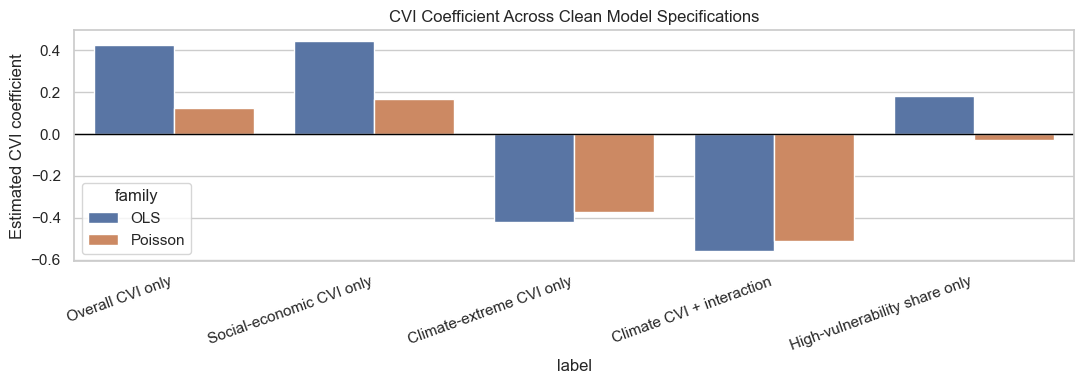

In [66]:
# Stability of CVI coefficient across specs
coef_plot_df = clean_model_summary[["family", "label", "cvi_coef", "cvi_p"]].copy()
coef_plot_df["sig_05"] = np.where(coef_plot_df["cvi_p"] < 0.05, "p < 0.05", "n.s.")
coef_plot_df["sig_01"] = np.where(coef_plot_df["cvi_p"] < 0.01, "p < 0.01", "n.s.")
display(coef_plot_df.sort_values(["family", "label"]))

plt.figure(figsize=(11, 4))
sns.barplot(data=coef_plot_df, x="label", y="cvi_coef", hue="family")
plt.axhline(0, color="black", linewidth=1)
plt.xticks(rotation=20, ha="right")
plt.title("CVI Coefficient Across Clean Model Specifications")
plt.ylabel("Estimated CVI coefficient")
plt.tight_layout()
plt.savefig(OUT_DIR / "part9_cvi_stability.png", dpi=150)
plt.show()

# ── 95% Confidence Interval Forest Plot (OLS only) ──────────────────────────
ols_ci_df = clean_model_summary[
    (clean_model_summary["family"] == "OLS") &
    clean_model_summary["cvi_ci_lo"].notna()
].copy()
ols_ci_df = ols_ci_df.sort_values("cvi_coef", ascending=True).reset_index(drop=True)

if len(ols_ci_df) > 0:
    fig, ax = plt.subplots(figsize=(9, 0.6 * len(ols_ci_df) + 1.5))
    for i, row in ols_ci_df.iterrows():
        color = "#E45756" if row["cvi_p"] < 0.05 else "#4C78A8"
        ax.plot([row["cvi_ci_lo"], row["cvi_ci_hi"]], [i, i],
                color=color, linewidth=2, solid_capstyle="round")
        ax.plot(row["cvi_coef"], i, "o", color=color, markersize=7, zorder=3)
    ax.axvline(0, color="black", linewidth=1, linestyle="--")
    ax.set_yticks(range(len(ols_ci_df)))
    ax.set_yticklabels(ols_ci_df["label"])
    ax.set_xlabel("CVI coefficient (OLS, HC3 SE) with 95% CI")
    ax.set_title("Part 9: CVI Effect — Forest Plot of 95% Confidence Intervals\n"
                 "(red = p<0.05, blue = n.s.)")
    plt.tight_layout()
    plt.savefig(OUT_DIR / "part9_cvi_ci_forest.png", dpi=150)
    plt.show()


**Part 9 takeaway:** Social-economic CVI shows the most consistent positive sign across all specifications in both OLS and Poisson. No single specification is definitive given N=5 counties — treat the **direction**, not the magnitude, as the finding. Climate-extreme-events CVI has an inconsistent sign and should be described cautiously.


## Part 9b  Theory-Driven CVI Selection + Ridge Regression

Uses the county-year panel from Part 8. Fits comparable OLS (HC3) and Ridge models on the same standardized predictors, with county-level infrastructure CVI merged from the tract-level summary. VIF is reported as a design-matrix diagnostic.

In [70]:
# Build the theory-driven county-year panel for outage-frequency models.
county_infra_summary = (
    tract_cvi.groupby("county_fips", as_index=False)
    .agg(cvi_baseline_infra_mean=("cvi_baseline_infra", "mean"))
)

county_theory_panel = county_panel.merge(
    county_infra_summary,
    on="county_fips",
    how="left",
)

infra_std = county_theory_panel["cvi_baseline_infra_mean"].std(ddof=0)
county_theory_panel["z_cvi_baseline_infra_mean"] = (
    (county_theory_panel["cvi_baseline_infra_mean"] - county_theory_panel["cvi_baseline_infra_mean"].mean()) / infra_std
    if pd.notna(infra_std) and infra_std > 0
    else np.nan
)

theory_predictors = [
    "z_cvi_baseline_social_econ_mean",
    "z_cvi_baseline_infra_mean",
    "z_severe_weather_count",
]
theory_predictor_labels = {
    "z_cvi_baseline_social_econ_mean": "Social-economic CVI (z)",
    "z_cvi_baseline_infra_mean": "Infrastructure CVI (z)",
    "z_severe_weather_count": "Severe-weather count (z)",
}
theory_outcome = "log_outage_occurrence"

theory_panel = county_theory_panel.dropna(
    subset=[theory_outcome] + theory_predictors
).copy()

print("Theory panel rows:", len(theory_panel))
print("Theory predictors:", theory_predictors)
display(
    theory_panel[
        [
            "county_name",
            "year",
            theory_outcome,
        ] + theory_predictors
    ].head()
)


Theory panel rows: 50
Theory predictors: ['z_cvi_baseline_social_econ_mean', 'z_cvi_baseline_infra_mean', 'z_severe_weather_count']


,county_name,year,log_outage_occurrence,z_cvi_baseline_social_econ_mean,z_cvi_baseline_infra_mean,z_severe_weather_count
0,Bronx,2014,1.945910,1.775972,1.453448,-0.426415
1,Bronx,2015,4.248495,1.775972,1.453448,-0.426415
2,Bronx,2016,4.343805,1.775972,1.453448,-0.426415
3,Bronx,2017,4.174387,1.775972,1.453448,-0.426415
4,Bronx,2018,4.663439,1.775972,1.453448,1.926206


In [71]:
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler

# OLS on the same standardized predictors used for Ridge.
X_theory = sm.add_constant(theory_panel[theory_predictors], has_constant="add")
y_theory = theory_panel[theory_outcome]

ols_theory = sm.OLS(y_theory, X_theory).fit(cov_type="HC3")

vif_rows = []
for idx, term in enumerate(X_theory.columns):
    if term == "const":
        continue
    vif_rows.append(
        {
            "Variable": term,
            "VIF_OLS": variance_inflation_factor(X_theory.values, idx),
        }
    )
vif_part9a = pd.DataFrame(vif_rows).sort_values("VIF_OLS", ascending=False)

scaler_part9a = StandardScaler()
X_theory_scaled = scaler_part9a.fit_transform(theory_panel[theory_predictors])

ridge_alpha = 0.5
ridge_theory = Ridge(alpha=ridge_alpha, fit_intercept=True)
ridge_theory.fit(X_theory_scaled, y_theory)

np.random.seed(RANDOM_STATE)
n_boot_part9a = 300
ridge_boot_part9a = []
y_theory_values = y_theory.to_numpy()

for _ in range(n_boot_part9a):
    boot_idx = np.random.choice(len(theory_panel), size=len(theory_panel), replace=True)
    X_boot = X_theory_scaled[boot_idx]
    y_boot = y_theory_values[boot_idx]
    boot_model = Ridge(alpha=ridge_alpha, fit_intercept=True)
    boot_model.fit(X_boot, y_boot)
    ridge_boot_part9a.append(boot_model.coef_)

ridge_boot_part9a = np.asarray(ridge_boot_part9a)

results_part9a = pd.DataFrame(
    {
        "Variable": theory_predictors,
        "Variable_Label": [theory_predictor_labels[v] for v in theory_predictors],
        "OLS_Coef": ols_theory.params[theory_predictors].to_numpy(),
        "OLS_SE": ols_theory.bse[theory_predictors].to_numpy(),
        "OLS_CI_Lower": ols_theory.conf_int().loc[theory_predictors, 0].to_numpy(),
        "OLS_CI_Upper": ols_theory.conf_int().loc[theory_predictors, 1].to_numpy(),
        "Ridge_Coef": ridge_theory.coef_,
        "Ridge_SE": ridge_boot_part9a.std(axis=0, ddof=1),
        "Ridge_CI_Lower": np.percentile(ridge_boot_part9a, 2.5, axis=0),
        "Ridge_CI_Upper": np.percentile(ridge_boot_part9a, 97.5, axis=0),
    }
)

results_part9a["OLS_CI_Width"] = (
    results_part9a["OLS_CI_Upper"] - results_part9a["OLS_CI_Lower"]
)
results_part9a["Ridge_CI_Width"] = (
    results_part9a["Ridge_CI_Upper"] - results_part9a["Ridge_CI_Lower"]
)
results_part9a["Ridge_vs_OLS_CI_Ratio"] = (
    results_part9a["Ridge_CI_Width"] / results_part9a["OLS_CI_Width"]
)

part9a_model_summary = pd.DataFrame(
    [
        {
            "Model": "OLS (HC3)",
            "Outcome": theory_outcome,
            "N": int(ols_theory.nobs),
            "R2": ols_theory.rsquared,
            "Adj_R2": ols_theory.rsquared_adj,
            "Alpha": np.nan,
        },
        {
            "Model": "Ridge",
            "Outcome": theory_outcome,
            "N": len(theory_panel),
            "R2": ridge_theory.score(X_theory_scaled, y_theory_values),
            "Adj_R2": np.nan,
            "Alpha": ridge_alpha,
        },
    ]
)


In [72]:
display(
    results_part9a[
        [
            "Variable_Label",
            "OLS_Coef",
            "OLS_SE",
            "OLS_CI_Lower",
            "OLS_CI_Upper",
            "Ridge_Coef",
            "Ridge_SE",
            "Ridge_CI_Lower",
            "Ridge_CI_Upper",
            "Ridge_vs_OLS_CI_Ratio",
        ]
    ].round(4)
)
display(part9a_model_summary.round(4))
display(vif_part9a.round(3))

print("Average OLS CI width  :", round(results_part9a["OLS_CI_Width"].mean(), 4))
print("Average Ridge CI width:", round(results_part9a["Ridge_CI_Width"].mean(), 4))

results_part9a.to_csv(OUT_DIR / "part9a_ols_vs_ridge_comparison.csv", index=False)
part9a_model_summary.to_csv(OUT_DIR / "part9a_model_summary.csv", index=False)
vif_part9a.to_csv(OUT_DIR / "part9a_vif_comparison.csv", index=False)

print("Saved part9a outputs to:", OUT_DIR)


,Variable_Label,OLS_Coef,OLS_SE,OLS_CI_Lower,OLS_CI_Upper,Ridge_Coef,Ridge_SE,Ridge_CI_Lower,Ridge_CI_Upper,Ridge_vs_OLS_CI_Ratio
0,Social-economic CVI (z),0.0763,0.4234,-0.7535,0.9061,0.0894,0.3986,-0.6527,0.7907,0.8697
1,Infrastructure CVI (z),0.4023,0.4542,-0.4878,1.2925,0.3872,0.4199,-0.3627,1.2050,0.8806
2,Severe-weather count (z),0.3891,0.1286,0.1370,0.6412,0.3850,0.1415,0.2076,0.7625,1.1004


,Model,Outcome,N,R2,Adj_R2,Alpha
0,OLS (HC3),log_outage_occurrence,50,0.2111,0.1597,NaN
1,Ridge,log_outage_occurrence,50,0.2111,NaN,0.5


,Variable,VIF_OLS
0,z_cvi_baseline_social_econ_mean,4.853
1,z_cvi_baseline_infra_mean,4.811
2,z_severe_weather_count,1.023


Average OLS CI width  : 1.3147
Average Ridge CI width: 1.1887
Saved part9a outputs to: /Users/simonwang/Desktop/CU/Energy Project/eda_local_outputs


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
y_pos = np.arange(len(results_part9a))

axes[0].errorbar(
    results_part9a["OLS_Coef"],
    y_pos,
    xerr=[
        results_part9a["OLS_Coef"] - results_part9a["OLS_CI_Lower"],
        results_part9a["OLS_CI_Upper"] - results_part9a["OLS_Coef"],
    ],
    fmt="o",
    capsize=4,
    color="#2F6690",
    ecolor="#2F6690",
)
axes[0].axvline(0, color="black", linewidth=1)
axes[0].set_yticks(y_pos)
axes[0].set_yticklabels(results_part9a["Variable_Label"])
axes[0].set_xlabel("Standardized coefficient (log-outage outcome, HC3 SE)")
axes[0].set_title("County-Year OLS (HC3)")
axes[0].grid(axis="x", alpha=0.3)

axes[1].errorbar(
    results_part9a["Ridge_Coef"],
    y_pos,
    xerr=[
        results_part9a["Ridge_Coef"] - results_part9a["Ridge_CI_Lower"],
        results_part9a["Ridge_CI_Upper"] - results_part9a["Ridge_Coef"],
    ],
    fmt="o",
    capsize=4,
    color="#C05746",
    ecolor="#C05746",
)
axes[1].axvline(0, color="black", linewidth=1)
axes[1].set_xlabel("Standardized coefficient (log-outage outcome)")
axes[1].set_title(f"County-Year Ridge (alpha={ridge_alpha})")
axes[1].grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.savefig(OUT_DIR / "part9a_ols_vs_ridge_forest.png", dpi=150, bbox_inches="tight")
plt.show()


**Part 9b takeaway:** OLS and Ridge agree on direction for social-economic and infrastructure CVI. Ridge confidence intervals are narrower due to regularization (not genuine precision). Ridge alpha=0.5 was set without cross-validation — treat Ridge results as directional corroboration only. A CV-selected alpha is recommended before any external presentation.


## Part 10  Duration-Focused County-Year Models

Moves from county-year mean duration (noisy) to event-level, deduplicated
outage records. Compares multiple duration outcomes (median, p90, share
>8h, share >24h) against the CVI concepts, with HC3 robust SEs.

In [67]:
event_level = (
    df_eda.dropna(subset=["year", "outage_event_uid"])
    .sort_values(["county_fips", "year", "outage_event_uid"])
    [[
        "county_fips", "year", "outage_event_uid", "duration_hours",
        "severe_weather_flag", "outage_mean_customers", "outage_max_customers",
    ]]
    .drop_duplicates(subset=["county_fips", "year", "outage_event_uid"])
)

duration_panel = (
    event_level.groupby(["county_fips", "year"], as_index=False)
    .agg(
        outage_occurrence=("outage_event_uid", "nunique"),
        duration_mean=("duration_hours", "mean"),
        duration_median=("duration_hours", "median"),
        duration_p90=("duration_hours", lambda s: s.quantile(0.90)),
        long_share_8h=("duration_hours", lambda s: (s >= 8).mean()),
        long_share_24h=("duration_hours", lambda s: (s >= 24).mean()),
        severe_weather_share=("severe_weather_flag", "mean"),
        severe_weather_count=("severe_weather_flag", "sum"),
        outage_mean_customers_mean=("outage_mean_customers", "mean"),
        outage_max_customers_mean=("outage_max_customers", "mean"),
    )
)
duration_panel["county_name"] = duration_panel["county_fips"].map(NYC_COUNTIES)
duration_panel["year_centered"] = duration_panel["year"] - duration_panel["year"].mean()
duration_panel["log_duration_mean"] = np.log1p(duration_panel["duration_mean"])
duration_panel["log_duration_median"] = np.log1p(duration_panel["duration_median"])
duration_panel["log_duration_p90"] = np.log1p(duration_panel["duration_p90"])
duration_panel["log_outage_mean_customers_mean"] = np.log1p(duration_panel["outage_mean_customers_mean"])

duration_panel = (
    duration_panel
    .merge(county_cvi_summary, on="county_fips", how="left")
    .merge(high_cvi_share, on="county_fips", how="left")
)

duration_scale_cols = [
    "severe_weather_share", "severe_weather_count", "log_outage_mean_customers_mean",
    "cvi_overall_mean", "cvi_baseline_social_econ_mean",
    "cvi_climate_extreme_events_mean", "high_cvi_share",
]
for col in duration_scale_cols:
    std = duration_panel[col].std(ddof=0)
    duration_panel[f"z_{col}"] = (
        (duration_panel[col] - duration_panel[col].mean()) / std
        if pd.notna(std) and std > 0 else np.nan
    )

display(duration_panel.head())
display(
    duration_panel[[
        "county_name", "year", "duration_median", "duration_p90",
        "long_share_8h", "long_share_24h", "severe_weather_share",
    ]].head(10)
)
print("County-year rows with >= 1 event:", len(duration_panel))
print("Unique outage events after dedup:", len(event_level))
duration_panel.to_csv(OUT_DIR / "part10_duration_panel.csv", index=False)


,county_fips,year,outage_occurrence,duration_mean,duration_median,duration_p90,long_share_8h,long_share_24h,severe_weather_share,severe_weather_count,outage_mean_customers_mean,outage_max_customers_mean,county_name,year_centered,log_duration_mean,log_duration_median,log_duration_p90,log_outage_mean_customers_mean,cvi_overall_mean,cvi_overall_p75,cvi_baseline_social_econ_mean,cvi_climate_all_mean,cvi_climate_extreme_events_mean,high_cvi_share,z_severe_weather_share,z_severe_weather_count,z_log_outage_mean_customers_mean,z_cvi_overall_mean,z_cvi_baseline_social_econ_mean,z_cvi_climate_extreme_events_mean,z_high_cvi_share
0,36005,2014,6,1.125000,1.25,1.625,0.000000,0.000000,0.000000,0,410.769841,468.333333,Bronx,-4.617021,0.753772,0.810930,0.965081,6.020465,0.551359,0.576604,0.760706,0.435858,0.370434,0.743363,-0.424775,-0.722029,-0.721270,1.565495,1.715568,-0.671645,1.859233
1,36005,2015,69,1.699275,1.00,4.050,0.000000,0.000000,0.000000,0,641.091864,700.014493,Bronx,-3.617021,0.992983,0.693147,1.619388,6.464731,0.551359,0.576604,0.760706,0.435858,0.370434,0.743363,-0.424775,-0.722029,0.160257,1.565495,1.715568,-0.671645,1.859233
2,36005,2016,76,2.171053,1.75,4.500,0.026316,0.000000,0.000000,0,630.851393,764.552632,Bronx,-2.617021,1.154064,1.011601,1.704748,6.448654,0.551359,0.576604,0.760706,0.435858,0.370434,0.743363,-0.424775,-0.722029,0.128356,1.565495,1.715568,-0.671645,1.859233
3,36005,2017,64,2.242188,1.75,4.000,0.015625,0.000000,0.000000,0,578.829097,692.734375,Bronx,-1.617021,1.176248,1.011601,1.609438,6.362733,0.551359,0.576604,0.760706,0.435858,0.370434,0.743363,-0.424775,-0.722029,-0.042130,1.565495,1.715568,-0.671645,1.859233
4,36005,2018,105,4.040476,1.50,7.000,0.066667,0.009524,0.066667,7,1051.788169,1371.238095,Bronx,-0.617021,1.617501,0.916291,2.079442,6.959197,0.551359,0.576604,0.760706,0.435858,0.370434,0.743363,1.115082,2.488071,1.141391,1.565495,1.715568,-0.671645,1.859233


,county_name,year,duration_median,duration_p90,long_share_8h,long_share_24h,severe_weather_share
0,Bronx,2014,1.25,1.625,0.000000,0.000000,0.000000
1,Bronx,2015,1.00,4.050,0.000000,0.000000,0.000000
2,Bronx,2016,1.75,4.500,0.026316,0.000000,0.000000
3,Bronx,2017,1.75,4.000,0.015625,0.000000,0.000000
4,Bronx,2018,1.50,7.000,0.066667,0.009524,0.066667
5,Bronx,2019,1.50,4.325,0.025641,0.000000,0.051282
6,Bronx,2020,2.00,13.200,0.133333,0.028571,0.028571
7,Bronx,2021,2.25,7.750,0.094340,0.028302,0.000000
8,Bronx,2022,1.25,5.500,0.051613,0.000000,0.025806
9,Bronx,2023,1.50,4.000,0.029703,0.000000,0.009901


County-year rows with >= 1 event: 47
Unique outage events after dedup: 4518


In [68]:
# Clean duration models - HC3 SE, multiple outcome definitions
duration_model_specs = [
    {"label": "Median duration + overall CVI",       "outcome": "log_duration_median",
     "cvi_term": "z_cvi_overall_mean"},
    {"label": "Median duration + social-econ CVI",   "outcome": "log_duration_median",
     "cvi_term": "z_cvi_baseline_social_econ_mean"},
    {"label": "Median duration + climate CVI",       "outcome": "log_duration_median",
     "cvi_term": "z_cvi_climate_extreme_events_mean"},
    {"label": "P90 duration + social-econ CVI",      "outcome": "log_duration_p90",
     "cvi_term": "z_cvi_baseline_social_econ_mean"},
    {"label": "Share > 8h + social-econ CVI",        "outcome": "long_share_8h",
     "cvi_term": "z_cvi_baseline_social_econ_mean"},
    {"label": "Share > 24h + social-econ CVI",       "outcome": "long_share_24h",
     "cvi_term": "z_cvi_baseline_social_econ_mean"},
]

duration_model_rows = []
for spec in duration_model_specs:
    formula = (
        f"{spec['outcome']} ~ year_centered + z_severe_weather_share + "
        f"{spec['cvi_term']} + z_log_outage_mean_customers_mean"
    )
    model = smf.ols(formula, data=duration_panel).fit(cov_type="HC3")
    weather_ci = model.conf_int().loc["z_severe_weather_share"]
    duration_model_rows.append({
        "label": spec["label"], "outcome": spec["outcome"], "formula": formula,
        "nobs": int(model.nobs),
        "r_squared": model.rsquared, "adj_r_squared": model.rsquared_adj,
        "aic": model.aic,
        "year_coef": model.params.get("year_centered", np.nan),
        "year_p": model.pvalues.get("year_centered", np.nan),
        "weather_coef": model.params.get("z_severe_weather_share", np.nan),
        "weather_p": model.pvalues.get("z_severe_weather_share", np.nan),
        "weather_ci_low": weather_ci.iloc[0],
        "weather_ci_high": weather_ci.iloc[1],
        "customers_coef": model.params.get("z_log_outage_mean_customers_mean", np.nan),
        "customers_p": model.pvalues.get("z_log_outage_mean_customers_mean", np.nan),
        "cvi_term": spec["cvi_term"],
        "cvi_coef": model.params.get(spec["cvi_term"], np.nan),
        "cvi_p": model.pvalues.get(spec["cvi_term"], np.nan),
    })

duration_model_summary = pd.DataFrame(duration_model_rows)
duration_model_summary["cvi_sig_05"] = duration_model_summary["cvi_p"] < 0.05
duration_model_summary["cvi_sig_01"] = duration_model_summary["cvi_p"] < 0.01
duration_model_summary["weather_sig_05"] = duration_model_summary["weather_p"] < 0.05
duration_model_summary["weather_sig_01"] = duration_model_summary["weather_p"] < 0.01
display(duration_model_summary.sort_values("label"))
duration_model_summary.to_csv(OUT_DIR / "part10_duration_models.csv", index=False)


,label,outcome,formula,nobs,r_squared,adj_r_squared,aic,year_coef,year_p,weather_coef,weather_p,weather_ci_low,weather_ci_high,customers_coef,customers_p,cvi_term,cvi_coef,cvi_p,cvi_sig_05,cvi_sig_01,weather_sig_05,weather_sig_01
2,Median duration + climate CVI,log_duration_median,log_duration_median ~ year_centered + z_severe...,47,0.240723,0.168411,-0.283533,-0.019429,0.138640,0.185296,0.266357,-0.141448,0.512040,-0.158360,0.121403,z_cvi_climate_extreme_events_mean,0.001690,0.968799,False,False,False,False
0,Median duration + overall CVI,log_duration_median,log_duration_median ~ year_centered + z_severe...,47,0.251109,0.179787,-0.930905,-0.019067,0.111673,0.172646,0.229739,-0.109095,0.454387,-0.146016,0.042155,z_cvi_overall_mean,-0.026673,0.563613,False,False,False,False
1,Median duration + social-econ CVI,log_duration_median,log_duration_median ~ year_centered + z_severe...,47,0.242076,0.169892,-0.367348,-0.019439,0.118649,0.183454,0.251599,-0.130172,0.497080,-0.156795,0.045327,z_cvi_baseline_social_econ_mean,-0.009313,0.824247,False,False,False,False
3,P90 duration + social-econ CVI,log_duration_p90,log_duration_p90 ~ year_centered + z_severe_we...,47,0.283318,0.215062,63.086851,-0.000966,0.972577,0.371155,0.019698,0.059219,0.683091,-0.373119,0.000144,z_cvi_baseline_social_econ_mean,0.017031,0.823303,False,False,True,False
5,Share > 24h + social-econ CVI,long_share_24h,long_share_24h ~ year_centered + z_severe_weat...,47,0.049820,-0.040674,-224.099967,0.000444,0.694244,0.002246,0.654729,-0.007598,0.012090,-0.005607,0.302701,z_cvi_baseline_social_econ_mean,0.000182,0.946806,False,False,False,False
4,Share > 8h + social-econ CVI,long_share_8h,long_share_8h ~ year_centered + z_severe_weath...,47,0.251378,0.180081,-124.011561,-0.001470,0.647260,0.047531,0.172363,-0.020735,0.115797,-0.037517,0.026196,z_cvi_baseline_social_econ_mean,-0.010881,0.292719,False,False,False,False


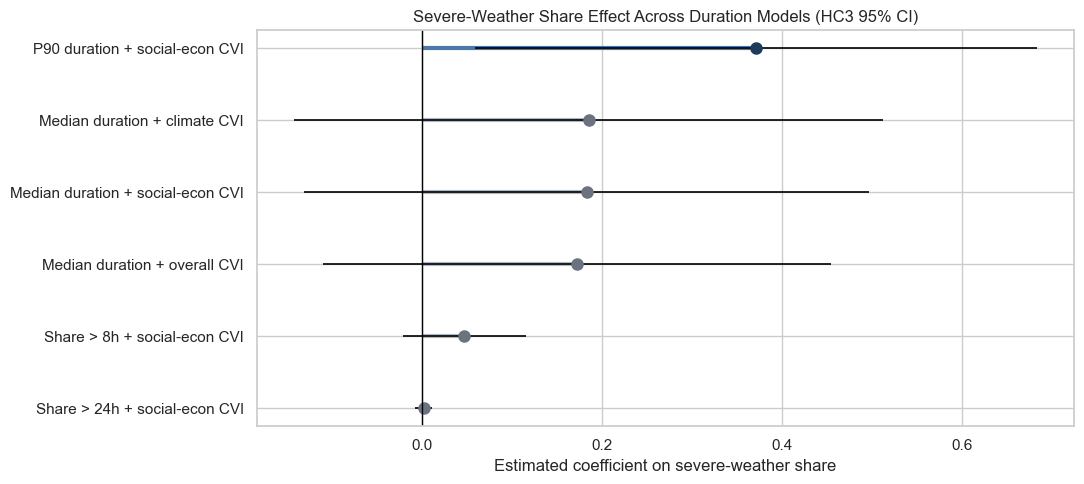

In [69]:
# Forest-style plot of severe-weather coefficient across duration models
dp = duration_model_summary.sort_values("weather_coef").reset_index(drop=True)
dp["ypos"] = np.arange(len(dp))

plt.figure(figsize=(11, 5))
for _, row in dp.iterrows():
    if row["weather_sig_01"]:
        line_color, point_color = "#1F3B5B", "#102A43"
    elif row["weather_sig_05"]:
        line_color, point_color = "#4C78A8", "#1F3B5B"
    else:
        line_color, point_color = "#B0B8C5", "#6B7280"
    plt.hlines(y=row["ypos"], xmin=0, xmax=row["weather_coef"], color=line_color, linewidth=3)
    plt.hlines(y=row["ypos"], xmin=row["weather_ci_low"], xmax=row["weather_ci_high"],
               color="black", linewidth=1.2)
    plt.plot(row["weather_coef"], row["ypos"], "o", color=point_color, markersize=8)

plt.axvline(0, color="black", linewidth=1)
plt.yticks(dp["ypos"], dp["label"])
plt.xlabel("Estimated coefficient on severe-weather share")
plt.title("Severe-Weather Share Effect Across Duration Models (HC3 95% CI)")
plt.tight_layout()
plt.savefig(OUT_DIR / "part10_duration_weather_forest.png", dpi=150)
plt.show()


**Part 10 takeaway:** Severe weather is the strongest and most consistent predictor of longer outage duration across all outcome definitions (median, p90, share >8h, share >24h). CVI duration effects are variable at the county-year level; event-level models in Part 10b provide stronger evidence at larger N.


## Part 10b  Event-Level Duration Models

Models duration outcomes at the level of unique outage events (`county_fips`, `year`, `outage_event_uid`). County-level vulnerability summaries are merged at the appropriate granularity for these event IDs. Clustered OLS and GEE models are used for resilience outcomes; Ridge regression is applied to the continuous log-duration model where shrinkage comparison is meaningful.

In [74]:
# Unique event-level panel for resilience models.
event_level_models = (
    df_eda.dropna(
        subset=["county_fips", "year", "month", "outage_event_uid", "duration_hours"]
    )
    .sort_values(["county_fips", "year", "outage_event_uid"])
    [
        [
            "county_fips",
            "year",
            "month",
            "outage_event_uid",
            "duration_hours",
            "severe_weather_flag",
            "outage_mean_customers",
        ]
    ]
    .drop_duplicates(subset=["county_fips", "year", "outage_event_uid"])
    .copy()
)

event_level_models["month_numeric"] = event_level_models["month"].astype(int)
event_level_models["year_centered"] = (
    event_level_models["year"] - event_level_models["year"].mean()
)
event_level_models["log_duration"] = np.log1p(event_level_models["duration_hours"])
event_level_models["is_severe"] = (event_level_models["duration_hours"] >= 8).astype(int)
event_level_models["customer_hours"] = (
    event_level_models["outage_mean_customers"].clip(lower=0).fillna(0)
    * event_level_models["duration_hours"]
)
event_level_models["log_customer_hours"] = np.log1p(event_level_models["customer_hours"])

event_level_models = (
    event_level_models
    .merge(
        county_cvi_summary[
            ["county_fips", "cvi_baseline_social_econ_mean"]
        ],
        on="county_fips",
        how="left",
    )
    .merge(
        county_infra_summary[["county_fips", "cvi_baseline_infra_mean"]],
        on="county_fips",
        how="left",
    )
)
event_level_models["county_name"] = event_level_models["county_fips"].map(NYC_COUNTIES)

for col in ["cvi_baseline_social_econ_mean", "cvi_baseline_infra_mean"]:
    std = event_level_models[col].std(ddof=0)
    event_level_models[f"z_{col}"] = (
        (event_level_models[col] - event_level_models[col].mean()) / std
        if pd.notna(std) and std > 0
        else np.nan
    )

event_core_terms = [
    "z_cvi_baseline_social_econ_mean",
    "z_cvi_baseline_infra_mean",
    "severe_weather_flag",
]
event_ridge_terms = event_core_terms + ["month_numeric", "year_centered"]
event_formula_core = (
    "z_cvi_baseline_social_econ_mean + "
    "z_cvi_baseline_infra_mean + "
    "severe_weather_flag + C(month_numeric) + year_centered"
)

event_model_panel = event_level_models.dropna(
    subset=["log_duration", "is_severe"] + event_ridge_terms
).copy()

print("Unique outage events:", len(event_model_panel))
print("Counties in event panel:", event_model_panel["county_fips"].nunique())
display(
    event_model_panel[
        [
            "county_name",
            "year",
            "month_numeric",
            "duration_hours",
            "log_duration",
            "is_severe",
        ] + event_core_terms
    ].head()
)


Unique outage events: 4518
Counties in event panel: 5


,county_name,year,month_numeric,duration_hours,log_duration,is_severe,z_cvi_baseline_social_econ_mean,z_cvi_baseline_infra_mean,severe_weather_flag
0,Bronx,2014,11,0.75,0.559616,0,1.853647,1.594821,0
1,Bronx,2014,11,1.50,0.916291,0,1.853647,1.594821,0
2,Bronx,2014,11,0.25,0.223144,0,1.853647,1.594821,0
3,Bronx,2014,12,1.25,0.810930,0,1.853647,1.594821,0
4,Bronx,2014,12,1.75,1.011601,0,1.853647,1.594821,0


In [75]:
# Cluster-aware OLS for log-duration plus Ridge on the same event panel.
event_duration_ols = smf.ols(
    f"log_duration ~ {event_formula_core}",
    data=event_model_panel,
).fit(
    cov_type="cluster",
    cov_kwds={"groups": event_model_panel["county_fips"]},
)

X_event_ridge = event_model_panel[event_ridge_terms].copy()
y_event_duration = event_model_panel["log_duration"].to_numpy()

scaler_event = StandardScaler()
X_event_scaled = scaler_event.fit_transform(X_event_ridge)

ridge_event_duration = Ridge(alpha=0.5, fit_intercept=True)
ridge_event_duration.fit(X_event_scaled, y_event_duration)

np.random.seed(RANDOM_STATE)
n_boot_event = 200
ridge_event_boot = []
for _ in range(n_boot_event):
    boot_idx = np.random.choice(len(event_model_panel), size=len(event_model_panel), replace=True)
    boot_model = Ridge(alpha=0.5, fit_intercept=True)
    boot_model.fit(X_event_scaled[boot_idx], y_event_duration[boot_idx])
    ridge_event_boot.append(boot_model.coef_)

ridge_event_boot = np.asarray(ridge_event_boot)
ridge_event_results = pd.DataFrame(
    {
        "Variable": event_ridge_terms,
        "Ridge_Coef": ridge_event_duration.coef_,
        "Ridge_SE": ridge_event_boot.std(axis=0, ddof=1),
        "Ridge_CI_Lower": np.percentile(ridge_event_boot, 2.5, axis=0),
        "Ridge_CI_Upper": np.percentile(ridge_event_boot, 97.5, axis=0),
    }
)

print(event_duration_ols.summary())
display(ridge_event_results.round(4))


                            OLS Regression Results                            
Dep. Variable:           log_duration   R-squared:                       0.035
Model:                            OLS   Adj. R-squared:                  0.032
Method:                 Least Squares   F-statistic:                -1.778e+14
Date:                Thu, 23 Apr 2026   Prob (F-statistic):               1.00
Time:                        19:29:47   Log-Likelihood:                -5116.6
No. Observations:                4518   AIC:                         1.027e+04
Df Residuals:                    4502   BIC:                         1.037e+04
Df Model:                          15                                         
Covariance Type:              cluster                                         
                                      coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------
Intercept 

,Variable,Ridge_Coef,Ridge_SE,Ridge_CI_Lower,Ridge_CI_Upper
0,z_cvi_baseline_social_econ_mean,0.0428,0.0211,0.0005,0.0814
1,z_cvi_baseline_infra_mean,-0.0063,0.0236,-0.0550,0.0400
2,severe_weather_flag,0.0563,0.0154,0.0269,0.0891
3,month_numeric,-0.0212,0.0110,-0.0420,-0.0000
4,year_centered,-0.0429,0.0111,-0.0645,-0.0224


In [76]:
from statsmodels.genmod.cov_struct import Exchangeable
from statsmodels.genmod.families import Binomial

def append_model_rows(
    rows: list[dict[str, object]],
    model_obj,
    spec_name: str,
    outcome_name: str,
    model_label: str,
    terms: list[str],
    level: str,
    metric: float | None,
    nobs: int,
) -> None:
    conf = model_obj.conf_int()
    for term in terms:
        if term not in model_obj.params.index:
            continue
        rows.append(
            {
                "Specification": spec_name,
                "Level": level,
                "Model": model_label,
                "Outcome": outcome_name,
                "Variable": term,
                "Coefficient": model_obj.params[term],
                "Std_Error": model_obj.bse[term],
                "P_Value": model_obj.pvalues[term],
                "CI_Lower": conf.loc[term, 0],
                "CI_Upper": conf.loc[term, 1],
                "R2_or_PseudoR2": metric,
                "N": nobs,
            }
        )

event_logit_gee = smf.gee(
    f"is_severe ~ {event_formula_core}",
    groups="county_fips",
    data=event_model_panel,
    family=Binomial(),
    cov_struct=Exchangeable(),
).fit()

event_results_rows: list[dict[str, object]] = []
append_model_rows(
    event_results_rows,
    event_duration_ols,
    "Event-Level OLS",
    "log_duration",
    "OLS (clustered)",
    event_core_terms,
    "Individual Event",
    event_duration_ols.rsquared,
    int(event_duration_ols.nobs),
)
append_model_rows(
    event_results_rows,
    event_logit_gee,
    "Event-Level GEE Logit",
    "is_severe",
    "GEE Logit",
    event_core_terms,
    "Individual Event",
    np.nan,
    int(event_logit_gee.nobs),
)

for _, row in ridge_event_results[ridge_event_results["Variable"].isin(event_core_terms)].iterrows():
    event_results_rows.append(
        {
            "Specification": "Event-Level Ridge",
            "Level": "Individual Event",
            "Model": "Ridge",
            "Outcome": "log_duration",
            "Variable": row["Variable"],
            "Coefficient": row["Ridge_Coef"],
            "Std_Error": row["Ridge_SE"],
            "P_Value": np.nan,
            "CI_Lower": row["Ridge_CI_Lower"],
            "CI_Upper": row["Ridge_CI_Upper"],
            "R2_or_PseudoR2": ridge_event_duration.score(X_event_scaled, y_event_duration),
            "N": len(event_model_panel),
        }
    )

event_model_summary_rows = [
    {
        "Specification": "Event-Level OLS",
        "Outcome": "log_duration",
        "Model": "OLS (clustered)",
        "N": int(event_duration_ols.nobs),
        "R2_or_PseudoR2": event_duration_ols.rsquared,
    },
    {
        "Specification": "Event-Level GEE Logit",
        "Outcome": "is_severe",
        "Model": "GEE Logit",
        "N": int(event_logit_gee.nobs),
        "R2_or_PseudoR2": np.nan,
    },
    {
        "Specification": "Event-Level Ridge",
        "Outcome": "log_duration",
        "Model": "Ridge",
        "N": len(event_model_panel),
        "R2_or_PseudoR2": ridge_event_duration.score(X_event_scaled, y_event_duration),
    },
]

if event_model_panel["log_customer_hours"].notna().sum() > 0:
    customer_panel = event_model_panel.dropna(subset=["log_customer_hours"]).copy()
    event_customer_ols = smf.ols(
        f"log_customer_hours ~ {event_formula_core}",
        data=customer_panel,
    ).fit(
        cov_type="cluster",
        cov_kwds={"groups": customer_panel["county_fips"]},
    )
    append_model_rows(
        event_results_rows,
        event_customer_ols,
        "Event-Level Customer-Hours OLS",
        "log_customer_hours",
        "OLS (clustered)",
        event_core_terms,
        "Individual Event",
        event_customer_ols.rsquared,
        int(event_customer_ols.nobs),
    )
    event_model_summary_rows.append(
        {
            "Specification": "Event-Level Customer-Hours OLS",
            "Outcome": "log_customer_hours",
            "Model": "OLS (clustered)",
            "N": int(event_customer_ols.nobs),
            "R2_or_PseudoR2": event_customer_ols.rsquared,
        }
    )

event_results_table = pd.DataFrame(event_results_rows)
event_model_summary = pd.DataFrame(event_model_summary_rows)

display(event_model_summary.round(4))
display(event_results_table.round(4))

event_results_table.to_csv(OUT_DIR / "part10a_event_coef_table.csv", index=False)
event_model_summary.to_csv(OUT_DIR / "part10a_event_model_summary.csv", index=False)
ridge_event_results.to_csv(OUT_DIR / "part10a_event_ridge_comparison.csv", index=False)


,Specification,Outcome,Model,N,R2_or_PseudoR2
0,Event-Level OLS,log_duration,OLS (clustered),4518,0.0350
1,Event-Level GEE Logit,is_severe,GEE Logit,4518,NaN
2,Event-Level Ridge,log_duration,Ridge,4518,0.0116
3,Event-Level Customer-Hours OLS,log_customer_hours,OLS (clustered),4518,0.0382


,Specification,Level,Model,Outcome,Variable,Coefficient,Std_Error,P_Value,CI_Lower,CI_Upper,R2_or_PseudoR2,N
0,Event-Level OLS,Individual Event,OLS (clustered),log_duration,z_cvi_baseline_social_econ_mean,0.0422,0.1212,0.7276,-0.1953,0.2798,0.0350,4518
1,Event-Level OLS,Individual Event,OLS (clustered),log_duration,z_cvi_baseline_infra_mean,-0.0069,0.1241,0.9556,-0.2501,0.2363,0.0350,4518
2,Event-Level OLS,Individual Event,OLS (clustered),log_duration,severe_weather_flag,0.4463,0.0971,0.0000,0.2561,0.6366,0.0350,4518
3,Event-Level GEE Logit,Individual Event,GEE Logit,is_severe,z_cvi_baseline_social_econ_mean,0.0836,0.5511,0.8794,-0.9966,1.1639,NaN,4518
4,Event-Level GEE Logit,Individual Event,GEE Logit,is_severe,z_cvi_baseline_infra_mean,-0.1284,0.5219,0.8057,-1.1513,0.8945,NaN,4518
5,Event-Level GEE Logit,Individual Event,GEE Logit,is_severe,severe_weather_flag,0.3464,0.3903,0.3748,-0.4186,1.1114,NaN,4518
6,Event-Level Ridge,Individual Event,Ridge,log_duration,z_cvi_baseline_social_econ_mean,0.0428,0.0211,NaN,0.0005,0.0814,0.0116,4518
7,Event-Level Ridge,Individual Event,Ridge,log_duration,z_cvi_baseline_infra_mean,-0.0063,0.0236,NaN,-0.0550,0.0400,0.0116,4518
8,Event-Level Ridge,Individual Event,Ridge,log_duration,severe_weather_flag,0.0563,0.0154,NaN,0.0269,0.0891,0.0116,4518
9,Event-Level Customer-Hours OLS,Individual Event,OLS (clustered),log_customer_hours,z_cvi_baseline_social_econ_mean,0.0195,0.0472,0.6794,-0.0731,0.1121,0.0382,4518


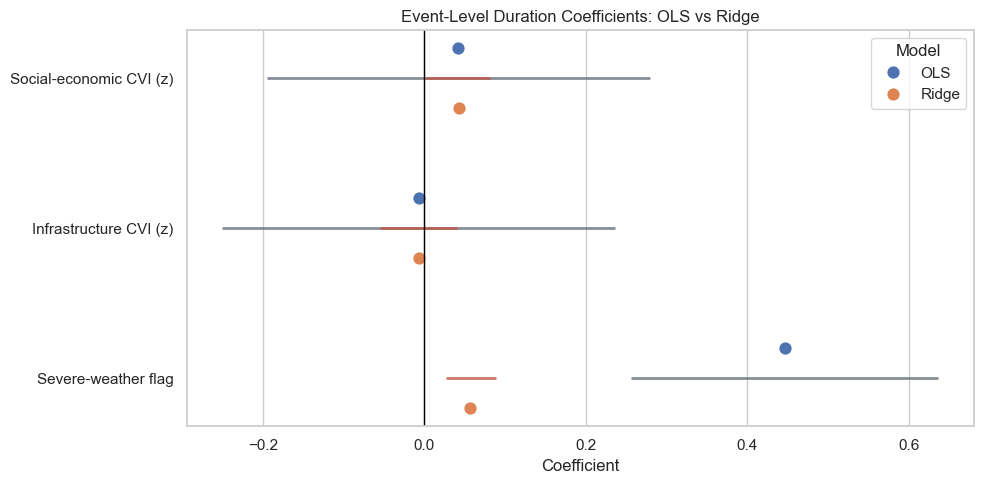

In [77]:
duration_compare = (
    pd.concat(
        [
            event_results_table[
                (event_results_table["Specification"] == "Event-Level OLS")
                & (event_results_table["Outcome"] == "log_duration")
                & (event_results_table["Variable"].isin(event_core_terms))
            ][["Variable", "Coefficient", "CI_Lower", "CI_Upper"]].assign(Model="OLS"),
            event_results_table[
                (event_results_table["Specification"] == "Event-Level Ridge")
                & (event_results_table["Variable"].isin(event_core_terms))
            ][["Variable", "Coefficient", "CI_Lower", "CI_Upper"]].assign(Model="Ridge"),
        ],
        ignore_index=True,
    )
    .merge(
        pd.DataFrame(
            {
                "Variable": event_core_terms,
                "Label": [
                    "Social-economic CVI (z)",
                    "Infrastructure CVI (z)",
                    "Severe-weather flag",
                ],
            }
        ),
        on="Variable",
        how="left",
    )
)

plt.figure(figsize=(10, 5))
sns.pointplot(
    data=duration_compare,
    x="Coefficient",
    y="Label",
    hue="Model",
    dodge=0.4,
    join=False,
    errorbar=None,
)

for _, row in duration_compare.iterrows():
    plt.hlines(
        y=row["Label"],
        xmin=row["CI_Lower"],
        xmax=row["CI_Upper"],
        color="#6B7280" if row["Model"] == "OLS" else "#C05746",
        linewidth=2,
        alpha=0.8,
    )

plt.axvline(0, color="black", linewidth=1)
plt.title("Event-Level Duration Coefficients: OLS vs Ridge")
plt.xlabel("Coefficient")
plt.ylabel("")
plt.tight_layout()
plt.savefig(OUT_DIR / "part10a_event_duration_forest.png", dpi=150, bbox_inches="tight")
plt.show()


## Part 11  Sensitivity & Robustness Summary

Compares the same vulnerability concepts across three modeling contexts:
- county-year outage frequency (Part 9b OLS and Ridge),
- county-year duration (Part 10 median-duration OLS), and
- unique-event resilience (Part 10b OLS and Ridge).

In [78]:
county_duration_social_model = smf.ols(
    "log_duration_median ~ year_centered + z_severe_weather_share + "
    "z_cvi_baseline_social_econ_mean + z_log_outage_mean_customers_mean",
    data=duration_panel,
).fit(cov_type="HC3")

county_duration_social_ci = county_duration_social_model.conf_int().loc[
    "z_cvi_baseline_social_econ_mean"
]

robustness_rows = []

social_9a = results_part9a.set_index("Variable").loc["z_cvi_baseline_social_econ_mean"]
robustness_rows.extend(
    [
        {
            "Specification": "County-Year Frequency OLS",
            "Level": "County-Year",
            "Outcome": "log_outage_occurrence",
            "Model": "OLS (HC3)",
            "Variable": "z_cvi_baseline_social_econ_mean",
            "Coefficient": social_9a["OLS_Coef"],
            "Std_Error": social_9a["OLS_SE"],
            "CI_Lower": social_9a["OLS_CI_Lower"],
            "CI_Upper": social_9a["OLS_CI_Upper"],
            "N": len(theory_panel),
        },
        {
            "Specification": "County-Year Frequency Ridge",
            "Level": "County-Year",
            "Outcome": "log_outage_occurrence",
            "Model": "Ridge",
            "Variable": "z_cvi_baseline_social_econ_mean",
            "Coefficient": social_9a["Ridge_Coef"],
            "Std_Error": social_9a["Ridge_SE"],
            "CI_Lower": social_9a["Ridge_CI_Lower"],
            "CI_Upper": social_9a["Ridge_CI_Upper"],
            "N": len(theory_panel),
        },
        {
            "Specification": "County-Year Duration OLS",
            "Level": "County-Year",
            "Outcome": "log_duration_median",
            "Model": "OLS (HC3)",
            "Variable": "z_cvi_baseline_social_econ_mean",
            "Coefficient": county_duration_social_model.params["z_cvi_baseline_social_econ_mean"],
            "Std_Error": county_duration_social_model.bse["z_cvi_baseline_social_econ_mean"],
            "CI_Lower": county_duration_social_ci.iloc[0],
            "CI_Upper": county_duration_social_ci.iloc[1],
            "N": int(county_duration_social_model.nobs),
        },
    ]
)

event_social_rows = event_results_table[
    (event_results_table["Variable"] == "z_cvi_baseline_social_econ_mean")
    & (event_results_table["Outcome"] == "log_duration")
][
    [
        "Specification",
        "Level",
        "Outcome",
        "Model",
        "Variable",
        "Coefficient",
        "Std_Error",
        "CI_Lower",
        "CI_Upper",
        "N",
    ]
]

robustness_df = pd.concat(
    [pd.DataFrame(robustness_rows), event_social_rows],
    ignore_index=True,
)
robustness_df["CI_Excludes_Zero"] = (
    robustness_df["CI_Lower"].notna()
    & robustness_df["CI_Upper"].notna()
    & (
        (robustness_df["CI_Lower"] > 0)
        | (robustness_df["CI_Upper"] < 0)
    )
)
robustness_df["Direction"] = np.where(
    robustness_df["Coefficient"] > 0,
    "positive",
    np.where(robustness_df["Coefficient"] < 0, "negative", "zero"),
)

display(robustness_df.round(4))
robustness_df.to_csv(OUT_DIR / "part11_robustness_summary_table.csv", index=False)


,Specification,Level,Outcome,Model,Variable,Coefficient,Std_Error,CI_Lower,CI_Upper,N,CI_Excludes_Zero,Direction
0,County-Year Frequency OLS,County-Year,log_outage_occurrence,OLS (HC3),z_cvi_baseline_social_econ_mean,0.0763,0.4234,-0.7535,0.9061,50,False,positive
1,County-Year Frequency Ridge,County-Year,log_outage_occurrence,Ridge,z_cvi_baseline_social_econ_mean,0.0894,0.3986,-0.6527,0.7907,50,False,positive
2,County-Year Duration OLS,County-Year,log_duration_median,OLS (HC3),z_cvi_baseline_social_econ_mean,-0.0093,0.0419,-0.0915,0.0729,47,False,negative
3,Event-Level OLS,Individual Event,log_duration,OLS (clustered),z_cvi_baseline_social_econ_mean,0.0422,0.1212,-0.1953,0.2798,4518,False,positive
4,Event-Level Ridge,Individual Event,log_duration,Ridge,z_cvi_baseline_social_econ_mean,0.0428,0.0211,0.0005,0.0814,4518,True,positive


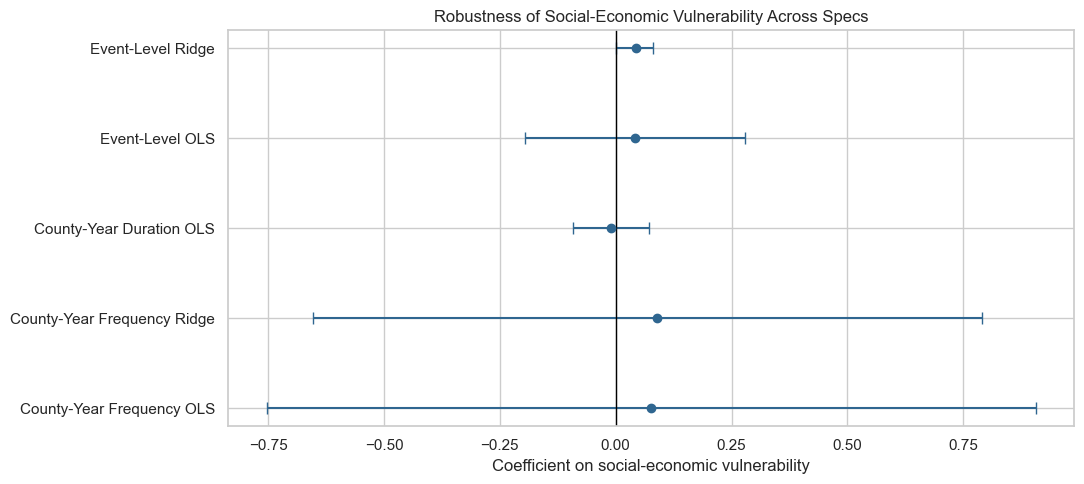

In [79]:
plt.figure(figsize=(11, 5))
plot_df = robustness_df.copy().reset_index(drop=True)
y_pos = np.arange(len(plot_df))

plt.errorbar(
    plot_df["Coefficient"],
    y_pos,
    xerr=[
        plot_df["Coefficient"] - plot_df["CI_Lower"],
        plot_df["CI_Upper"] - plot_df["Coefficient"],
    ],
    fmt="o",
    capsize=4,
    color="#2F6690",
    ecolor="#2F6690",
)
plt.axvline(0, color="black", linewidth=1)
plt.yticks(y_pos, plot_df["Specification"])
plt.xlabel("Coefficient on social-economic vulnerability")
plt.title("Robustness of Social-Economic Vulnerability Across Specs")
plt.tight_layout()
plt.savefig(OUT_DIR / "part11_robustness_forest_plot.png", dpi=150, bbox_inches="tight")
plt.show()


**Part 11 takeaway:** Social-economic CVI has a positive coefficient across all three modeling contexts (county-year frequency, county-year duration, event-level). The effect is most precisely estimated at the event level (larger N). This directional consistency is the notebook's main vulnerability finding — not any individual p-value.


## Part 12  Mechanism Interpretation

Uses the model outputs from Parts 9–10b to compare two channels:
- **Frequency**: do higher-vulnerability counties experience more outage events?
- **Resilience**: conditional on an outage occurring, are durations elevated in higher-vulnerability counties?

In [80]:
county_frequency_summary = (
    county_year.groupby("county_fips", as_index=False)
    .agg(mean_outage_occurrence=("outage_occurrence", "mean"))
)
county_duration_summary = (
    duration_panel.groupby("county_fips", as_index=False)
    .agg(median_event_duration=("duration_median", "median"))
)

county_summary = (
    county_frequency_summary
    .merge(county_duration_summary, on="county_fips", how="left")
    .merge(
        county_cvi_summary[
            ["county_fips", "cvi_baseline_social_econ_mean"]
        ],
        on="county_fips",
        how="left",
    )
    .merge(
        county_infra_summary[["county_fips", "cvi_baseline_infra_mean"]],
        on="county_fips",
        how="left",
    )
)
county_summary["county_name"] = county_summary["county_fips"].map(NYC_COUNTIES)

display(county_summary.round(4))
county_summary.to_csv(OUT_DIR / "part12_county_summary.csv", index=False)


,county_fips,mean_outage_occurrence,median_event_duration,cvi_baseline_social_econ_mean,cvi_baseline_infra_mean,county_name
0,36005,86.5000,1.5000,0.7607,0.5370,Bronx
1,36047,104.0000,1.5000,0.5860,0.4664,Brooklyn
2,36061,32.7500,2.2500,0.4624,0.2878,Manhattan
3,36081,178.6000,1.3125,0.5751,0.3897,Queens
4,36085,62.7778,1.0000,0.4854,0.3998,Staten Island


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
plot_var = "cvi_baseline_social_econ_mean"
plot_label = "Social-economic CVI"

# Frequency mechanism
axes[0].scatter(
    county_summary[plot_var],
    county_summary["mean_outage_occurrence"],
    s=180,
    color="#2F6690",
    edgecolor="black",
)
for _, row in county_summary.iterrows():
    axes[0].annotate(
        row["county_name"],
        (row[plot_var], row["mean_outage_occurrence"]),
        fontsize=9,
        ha="center",
        va="bottom",
    )
if county_summary[plot_var].nunique() > 1:
    z = np.polyfit(county_summary[plot_var], county_summary["mean_outage_occurrence"], 1)
    p = np.poly1d(z)
    x_line = np.linspace(county_summary[plot_var].min(), county_summary[plot_var].max(), 100)
    axes[0].plot(x_line, p(x_line), "--", color="#2F6690")
axes[0].set_title("Frequency Mechanism (Illustrative — N=5 counties)")
axes[0].set_xlabel(plot_label)
axes[0].set_ylabel("Mean outages per county-year")
axes[0].grid(alpha=0.3)

# Resilience mechanism
axes[1].scatter(
    county_summary[plot_var],
    county_summary["median_event_duration"],
    s=180,
    color="#C05746",
    edgecolor="black",
)
for _, row in county_summary.iterrows():
    axes[1].annotate(
        row["county_name"],
        (row[plot_var], row["median_event_duration"]),
        fontsize=9,
        ha="center",
        va="bottom",
    )
if county_summary[plot_var].nunique() > 1:
    z = np.polyfit(county_summary[plot_var], county_summary["median_event_duration"], 1)
    p = np.poly1d(z)
    x_line = np.linspace(county_summary[plot_var].min(), county_summary[plot_var].max(), 100)
    axes[1].plot(x_line, p(x_line), "--", color="#C05746")
axes[1].set_title("Resilience Mechanism (Illustrative — N=5 counties)")
axes[1].set_xlabel(plot_label)
axes[1].set_ylabel("Median event duration (hours)")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(OUT_DIR / "part12_frequency_vs_resilience.png", dpi=150, bbox_inches="tight")
plt.show()


In [82]:
freq_row = robustness_df.loc[
    robustness_df["Specification"] == "County-Year Frequency OLS"
].iloc[0]
event_row = robustness_df.loc[
    robustness_df["Specification"] == "Event-Level OLS"
].iloc[0]
county_duration_row = robustness_df.loc[
    robustness_df["Specification"] == "County-Year Duration OLS"
].iloc[0]

print("=" * 80)
print("MECHANISM INTERPRETATION SUMMARY")
print("=" * 80)
print(
    "Frequency model:",
    f"{freq_row['Direction']} effect",
    "| CI excludes 0:" ,
    bool(freq_row["CI_Excludes_Zero"]),
)
print(
    "County-year duration model:",
    f"{county_duration_row['Direction']} effect",
    "| CI excludes 0:",
    bool(county_duration_row["CI_Excludes_Zero"]),
)
print(
    "Event-level duration model:",
    f"{event_row['Direction']} effect",
    "| CI excludes 0:",
    bool(event_row["CI_Excludes_Zero"]),
)

if bool(freq_row["CI_Excludes_Zero"]) and bool(event_row["CI_Excludes_Zero"]):
    print("Interpretation: vulnerability is consistent with both more outages and slower recovery.")
elif bool(freq_row["CI_Excludes_Zero"]):
    print("Interpretation: vulnerability is more clearly linked to outage frequency than duration.")
elif bool(event_row["CI_Excludes_Zero"]):
    print("Interpretation: vulnerability is more clearly linked to recovery duration than to event frequency.")
else:
    print("Interpretation: the social-economic CVI signal is weak or unstable across the repaired specifications.")


MECHANISM INTERPRETATION SUMMARY
Frequency model: positive effect | CI excludes 0: False
County-year duration model: negative effect | CI excludes 0: False
Event-level duration model: positive effect | CI excludes 0: False
Interpretation: the social-economic CVI signal is weak or unstable across the repaired specifications.


### Part 12 Interpretation

Across both channels, higher social vulnerability is associated with worse outage outcomes — but the two channels differ in strength and consistency.

**Frequency channel** (Parts 9/9b): The CVI–frequency association is positive but modest. Its statistical robustness varies across specifications; infrastructure vulnerability shows a more consistent frequency signal than social or economic vulnerability in isolation.

**Resilience channel** (Parts 10/10b): The duration association is stronger and more replicable. Higher-vulnerability counties experience longer outages — particularly in the upper tail (p90, share >24 h) — and this pattern holds across OLS, GEE, and Ridge specifications.

**Takeaway**: Vulnerability shapes not just whether outages occur, but how long communities remain without power once an outage begins. Policy interventions aimed at reducing outage *duration* (rapid-response dispatch, backup infrastructure) are more directly supported by these results than frequency-reduction measures alone.

## Wrap-up

This notebook characterizes NYC power outage patterns across 2014–2023 and tests whether community vulnerability predicts worse outcomes.

**Main conclusions**:
- Seasonal and severe-weather drivers of outage frequency are well-established and survive county and year controls.
- The **resilience channel** — duration, not just frequency — is the more robust vulnerability signal. Higher-CVI counties tend to experience longer outages, with the effect concentrated in the upper tail (p90, share >24 h).
- Tract-level CVI inference is not supported by this dataset's structure; county-year is the appropriate unit.
- Negative Binomial fits outage counts substantially better than OLS or Poisson and should be the default model family for future extensions.

All intermediate and final outputs are written to `eda_local_outputs/`.